# Brand Visibility in Large Language Models: A Generative Engine Optimization Analysis

This notebook investigates factors influencing brand visibility and positioning in LLM responses, specifically ChatGPT outputs from the LMSYS-Chat-1M dataset.

## Research Questions

1. **Position Analysis:** Which brands consistently achieve top positions (1st, 2nd, 3rd) in LLM recommendations?
2. **Sentiment and Context:** How are brands described, and does sentiment correlate with positioning?
3. **Competitive Dynamics:** Which brands appear together, revealing competitive landscapes?
4. **Query Pattern Optimization:** What query phrasings maximize brand visibility and favorable positioning?


## Section 0: Setup and Configuration

Install and import required libraries, set up BigQuery client, and configure the analysis environment.


In [1]:
# Install required packages (run this cell first, then restart kernel)
# If packages are already installed, you can skip this cell

%pip install -q datasets pandas numpy matplotlib seaborn plotly
%pip install -q google-cloud-bigquery google-cloud-bigquery-storage
%pip install -q textblob pytrends networkx huggingface_hub scikit-learn requests

print("✓ Package installation complete!")
print("Restart the kernel after installation, then run the import cell below.")



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✓ Package installation complete!
Restart the kernel after installation, then run the import cell below.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime
from collections import Counter, defaultdict
import warnings
import requests
import time
warnings.filterwarnings('ignore')

# Data loading
from datasets import load_dataset
from huggingface_hub import login as hf_login

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx

# BigQuery
from google.cloud import bigquery
from google.cloud.bigquery import SchemaField

# Sentiment analysis
from textblob import TextBlob

# Google Trends (optional)
try:
    from pytrends.request import TrendReq
    PTRENDS_AVAILABLE = True
except ImportError:
    PTRENDS_AVAILABLE = False
    print("pytrends not available - Google Trends analysis will be skipped")

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# BigQuery Setup
PROJECT_ID = "project-478723"  
DATASET_ID = "geo_analysis"     

# Initialize BigQuery client
print("Initializing BigQuery client...")
try:
    client = bigquery.Client(project=PROJECT_ID)
    print(f"✓ BigQuery client initialized for project: {PROJECT_ID}")
except Exception as e:
    print(f"✗ BigQuery initialization failed: {e}")
    print("\nTo fix this, run the following command in your terminal:")
    print("  gcloud auth application-default login")
    print("\nOr if you're using a service account, set the GOOGLE_APPLICATION_CREDENTIALS environment variable:")
    print("  export GOOGLE_APPLICATION_CREDENTIALS=/path/to/your/service-account-key.json")
    print("\nAfter authentication, restart the kernel and run this cell again.")
    client = None


Initializing BigQuery client...
✓ BigQuery client initialized for project: project-478723


## Section 1: Project Overview and Dataset Introduction

### Objectives
- Load LMSYS-Chat-1M dataset from HuggingFace
- Filter for ChatGPT models (gpt-3.5-turbo, gpt-4)
- Perform strategic sampling (200K conversations)
- Analyze dataset structure and quality


In [4]:
# HuggingFace Login
# If not already logged in, run: huggingface-cli login
# Or use token: hf_login(token="your-token-here")

try:
    # Try to load dataset (will prompt for login if needed)
    print("Loading LMSYS-Chat-1M dataset...")
    print("If you see an authentication error, run: huggingface-cli login")
    dataset = load_dataset("lmsys/lmsys-chat-1m", split="train")
    print(f"Dataset loaded successfully! Total conversations: {len(dataset)}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("\nTo fix this:")
    print("1. Install: pip install huggingface_hub")
    print("2. Login: huggingface-cli login")
    print("3. Accept the dataset license at: https://huggingface.co/datasets/lmsys/lmsys-chat-1m")
    raise


Loading LMSYS-Chat-1M dataset...
If you see an authentication error, run: huggingface-cli login
Dataset loaded successfully! Total conversations: 1000000


In [5]:
# Explore dataset structure
print("Dataset features:", dataset.features)
print("\nSample conversation structure:")
sample = dataset[0]
for key in sample.keys():
    print(f"  {key}: {type(sample[key])}")
    if isinstance(sample[key], (str, list)) and len(str(sample[key])) < 200:
        print(f"    Example: {str(sample[key])[:100]}...")


Dataset features: {'conversation_id': Value('string'), 'model': Value('string'), 'conversation': List({'content': Value('string'), 'role': Value('string')}), 'turn': Value('int64'), 'language': Value('string'), 'openai_moderation': List({'categories': {'harassment': Value('bool'), 'harassment/threatening': Value('bool'), 'hate': Value('bool'), 'hate/threatening': Value('bool'), 'self-harm': Value('bool'), 'self-harm/instructions': Value('bool'), 'self-harm/intent': Value('bool'), 'sexual': Value('bool'), 'sexual/minors': Value('bool'), 'violence': Value('bool'), 'violence/graphic': Value('bool')}, 'category_scores': {'harassment': Value('float64'), 'harassment/threatening': Value('float64'), 'hate': Value('float64'), 'hate/threatening': Value('float64'), 'self-harm': Value('float64'), 'self-harm/instructions': Value('float64'), 'self-harm/intent': Value('float64'), 'sexual': Value('float64'), 'sexual/minors': Value('float64'), 'violence': Value('float64'), 'violence/graphic': Value('fl

In [6]:
# Filter for ChatGPT models
CHATGPT_MODELS = ['gpt-3.5-turbo', 'gpt-4', 'gpt-4-turbo', 'gpt-4-turbo-preview']

def filter_chatgpt(example):
    """Filter to only ChatGPT models"""
    model = example.get('model', '').lower()
    return any(gpt_model in model for gpt_model in CHATGPT_MODELS)

print("Filtering for ChatGPT models...")
chatgpt_dataset = dataset.filter(filter_chatgpt)
print(f"ChatGPT conversations: {len(chatgpt_dataset)} ({len(chatgpt_dataset)/len(dataset)*100:.1f}% of total)")

# Check model distribution
if 'model' in chatgpt_dataset.features:
    model_counts = Counter([ex.get('model', 'unknown') for ex in chatgpt_dataset])
    print("\nModel distribution:")
    for model, count in model_counts.most_common():
        print(f"  {model}: {count:,}")


Filtering for ChatGPT models...
ChatGPT conversations: 14882 (1.5% of total)

Model distribution:
  gpt-3.5-turbo: 7,578
  gpt-4: 7,304


In [7]:
# Strategic Sampling: Target 200K conversations
TARGET_SAMPLE_SIZE = 200000

if len(chatgpt_dataset) > TARGET_SAMPLE_SIZE:
    print(f"Sampling {TARGET_SAMPLE_SIZE:,} conversations from {len(chatgpt_dataset):,} total...")
    sampled_dataset = chatgpt_dataset.shuffle(seed=RANDOM_SEED).select(range(TARGET_SAMPLE_SIZE))
    print(f"Sampled {len(sampled_dataset):,} conversations")
else:
    print(f"Using all {len(chatgpt_dataset):,} ChatGPT conversations (less than target)")
    sampled_dataset = chatgpt_dataset


Using all 14,882 ChatGPT conversations (less than target)


In [8]:
# Convert to pandas for easier manipulation
print("Converting to pandas DataFrame...")
conversations_list = []

for i, example in enumerate(sampled_dataset):
    if i % 10000 == 0:
        print(f"  Processed {i:,} conversations...")
    
    conv_id = example.get('conversation_id', i)
    model = example.get('model', 'unknown')
    
    # Parse conversation JSON
    try:
        if isinstance(example.get('conversation'), str):
            conv_data = json.loads(example['conversation'])
        else:
            conv_data = example.get('conversation', [])
        
        # Extract user query (first user message) and assistant response (first assistant message)
        user_query = ""
        assistant_response = ""
        
        for msg in conv_data:
            role = msg.get('role', '').lower()
            content = msg.get('content', '')
            
            if role == 'user' and not user_query:
                user_query = content
            elif role == 'assistant' and not assistant_response:
                assistant_response = content
                break  # We only need first response
        
        if user_query and assistant_response:
            conversations_list.append({
                'conversation_id': conv_id,
                'model': model,
                'user_query': user_query,
                'assistant_response': assistant_response,
                'response_length': len(assistant_response),
                'query_length': len(user_query),
            })
    except Exception as e:
        continue

conversations_df = pd.DataFrame(conversations_list)
print(f"\nCreated DataFrame with {len(conversations_df):,} valid conversations")
print(f"Average response length: {conversations_df['response_length'].mean():.1f} characters")
print(f"Average query length: {conversations_df['query_length'].mean():.1f} characters")


Converting to pandas DataFrame...
  Processed 0 conversations...
  Processed 10,000 conversations...

Created DataFrame with 14,881 valid conversations
Average response length: 751.7 characters
Average query length: 221.6 characters


In [9]:
# Dataset statistics and quality assessment
print("=== Dataset Statistics ===")
print(f"Total conversations: {len(conversations_df):,}")
print(f"Unique models: {conversations_df['model'].nunique()}")
print(f"\nResponse length statistics:")
print(conversations_df['response_length'].describe())
print(f"\nQuery length statistics:")
print(conversations_df['query_length'].describe())

# Check for very short responses (might be low quality)
short_responses = (conversations_df['response_length'] < 50).sum()
print(f"\nVery short responses (<50 chars): {short_responses:,} ({short_responses/len(conversations_df)*100:.1f}%)")

# Sample conversations
print("\n=== Sample Conversations ===")
for idx in range(min(3, len(conversations_df))):
    print(f"\n--- Conversation {idx+1} ---")
    print(f"Query: {conversations_df.iloc[idx]['user_query'][:200]}...")
    print(f"Response (first 200 chars): {conversations_df.iloc[idx]['assistant_response'][:200]}...")


=== Dataset Statistics ===
Total conversations: 14,881
Unique models: 2

Response length statistics:
count    14881.000000
mean       751.699953
std        827.078786
min          1.000000
25%        130.000000
50%        445.000000
75%       1143.000000
max       8717.000000
Name: response_length, dtype: float64

Query length statistics:
count    14881.000000
mean       221.607217
std        445.780082
min          1.000000
25%         31.000000
50%         63.000000
75%        155.000000
max       2637.000000
Name: query_length, dtype: float64

Very short responses (<50 chars): 2,146 (14.4%)

=== Sample Conversations ===

--- Conversation 1 ---
Query: write a performance review for a junior data scientist ...
Response (first 200 chars): Performance Review for Junior Data Scientist

Employee: [Employee Name]
Position: Junior Data Scientist
Review Period: [Review Period]

Performance Summary:

1. Technical Skills: [Employee Name] has d...

--- Conversation 2 ---
Query: Was wird mit §38

## Section 2: Brand Identification and Supplementary Data Integration

### Objectives
- Define brand universe (100-150 brands across 4 industries)
- Extract brand mentions with position and context
- Perform sentiment analysis
- Classify query intents and patterns
- Integrate supplementary data (company metadata, Wikipedia, Google Trends)


### Methodology Example: Understanding Brand Mentions and Positions

To help readers understand our methodology, here's a concrete example showing how we extract brand mentions and determine their positions in LLM responses.


In [ ]:
# Example: Brand Mention Extraction and Position Methodology
print("=" * 80)
print("EXAMPLE: Brand Mention Extraction and Position Analysis")
print("=" * 80)

# Sample user query
example_query = "What are the best smartphones to buy in 2024?"

# Sample LLM response (simulated based on typical ChatGPT responses)
example_response = """Based on current market trends, here are some excellent smartphone options for 2024:

1. **Apple iPhone 15 Pro** - Apple continues to lead with exceptional build quality and the A17 Pro chip. The camera system is outstanding.

2. **Samsung Galaxy S24 Ultra** - Samsung offers the best Android experience with the S Pen and incredible display technology.

3. **Google Pixel 8 Pro** - Google excels at computational photography and provides a clean Android experience.

4. **OnePlus 12** - Great value proposition with flagship features at a lower price point.

Each brand has its strengths: Apple for ecosystem integration, Samsung for versatility, and Google for photography."""

print("\n📝 USER QUERY:")
print(f"   \"{example_query}\"")
print("\n🤖 LLM RESPONSE:")
print(example_response)

# Extract brand mentions
example_brands = ['Apple', 'Samsung', 'Google', 'OnePlus']
example_mentions = []

# Find all brand mentions with positions
for brand in example_brands:
    pattern = r'\b' + re.escape(brand) + r'\b'
    for match in re.finditer(pattern, example_response, re.IGNORECASE):
        example_mentions.append({
            'brand': brand,
            'position': match.start(),
            'text': match.group()
        })

# Sort by position to determine rank
example_mentions.sort(key=lambda x: x['position'])

print("\n" + "=" * 80)
print("BRAND MENTION EXTRACTION:")
print("=" * 80)

# Visualize with position markers
response_with_markers = example_response
offset = 0
for i, mention in enumerate(example_mentions, 1):
    pos = mention['position'] + offset
    marker = f"[POSITION {i}]"
    response_with_markers = (response_with_markers[:pos] + 
                             f" {marker} " + 
                             response_with_markers[pos:])
    offset += len(marker) + 2

print("\n📍 Response with Position Markers:")
print(response_with_markers)

print("\n" + "=" * 80)
print("POSITION ANALYSIS:")
print("=" * 80)

# Create a clear position table
position_data = []
for i, mention in enumerate(example_mentions, 1):
    # Get context (50 chars before and after)
    start_ctx = max(0, mention['position'] - 50)
    end_ctx = min(len(example_response), mention['position'] + len(mention['brand']) + 50)
    context = example_response[start_ctx:end_ctx]
    
    position_data.append({
        'Rank': i,
        'Brand': mention['brand'],
        'Position in Text': mention['position'],
        'Context Snippet': f"...{context}..."
    })

position_df = pd.DataFrame(position_data)
print("\n📊 Brand Position Summary:")
print(position_df.to_string(index=False))

print("\n" + "=" * 80)
print("KEY INSIGHTS FROM THIS EXAMPLE:")
print("=" * 80)
print("""
1. **Position 1 (Apple)**: First brand mentioned - highest visibility
   - Appears in the #1 recommendation spot
   - Gets the most attention from readers
   
2. **Position 2 (Samsung)**: Second brand mentioned - high visibility
   - Still very visible but less prominent than Position 1
   
3. **Position 3 (Google)**: Third brand mentioned - moderate visibility
   - Still visible but readers may not scroll this far
   
4. **Position 4 (OnePlus)**: Fourth brand mentioned - lower visibility
   - Least visible, may be missed by some readers

**Why Position Matters:**
- Position 1 brands get the most attention and clicks
- Users often stop reading after the first few recommendations
- Higher positions correlate with brand recall and consideration
- This is why "Position 1 Win Rate" is a critical GEO metric
""")

print("=" * 80)


In [ ]:
# Define Brand Universe
BRAND_UNIVERSE = {
    'Technology': [
        # Consumer devices
        'Apple', 'Samsung', 'Google', 'Dell', 'HP', 'Lenovo', 'Microsoft', 'Sony',
        # Software and cloud
        'Adobe', 'Salesforce', 'AWS', 'Azure', 'Google Cloud', 'Oracle', 'IBM',
        # Social media and platforms
        'Meta', 'Facebook', 'Twitter', 'X',  # Note: 'X' is filtered to only match brand contexts (not code variables)
        'TikTok', 'LinkedIn', 'Reddit', 'Discord', 'Snapchat',
        # Entertainment
        'Netflix', 'Spotify', 'YouTube', 'Twitch', 'Disney', 'Amazon Prime'
    ],
    'E-commerce': [
        'Amazon', 'eBay', 'Alibaba', 'Etsy', 'Shopify', 'Walmart', 'Target', 
        'Best Buy', 'Costco', 'Home Depot', 'Wayfair', 'Chewy', 'Zappos'
    ],
    'Food and Beverage': [
        # Fast food
        "McDonald's", 'McDonalds', 'Burger King', "Wendy's", 'KFC', 'Taco Bell', 'Chipotle', 'Subway',
        # Coffee
        'Starbucks', "Dunkin'", 'Dunkin Donuts', 'Peet\'s Coffee',
        # Beverages
        'Coca-Cola', 'Coke', 'Pepsi', 'Red Bull', 'Monster',
        # Delivery
        'DoorDash', 'Uber Eats', 'Grubhub', 'Instacart', 'Postmates'
    ],
    'Automotive': [
        # Traditional
        'Toyota', 'Honda', 'Ford', 'BMW', 'Mercedes-Benz', 'Mercedes', 'Volkswagen', 'Audi', 'Nissan',
        # Electric
        'Tesla', 'Rivian', 'Lucid', 'Polestar', 'BYD',
        # Ride-sharing
        'Uber', 'Lyft'
    ]
}

# Flatten to single list with industry mapping
brand_to_industry = {}
all_brands = []
for industry, brands in BRAND_UNIVERSE.items():
    for brand in brands:
        all_brands.append(brand)
        brand_to_industry[brand] = industry

print(f"Total brands: {len(all_brands)}")
for industry, brands in BRAND_UNIVERSE.items():
    print(f"  {industry}: {len(brands)} brands")


Total brands: 81
  Technology: 30 brands
  E-commerce: 13 brands
  Food and Beverage: 22 brands
  Automotive: 16 brands


In [40]:
# Brand mention extraction function
def extract_brand_mentions(text, brands, context_window=50):
    """
    Extract brand mentions with position and context.
    Returns list of (brand, position, rank, context) tuples.
    """
    mentions = []
    text_lower = text.lower()
    
    # Sort brands by length (longest first) to avoid partial matches
    brands_sorted = sorted(brands, key=len, reverse=True)
    
    found_positions = []
    brand_rank = {}
    
    # Brand context keywords - for ambiguous brands that are also common words
    brand_context_keywords = {
        'X': ['twitter', 'platform', 'social media', 'formerly twitter', 'x.com', 'musk', 'elon', 'social network'],
        'Target': ['target store', 'target corporation', 'target.com', 'target retail', 'shopping at target', 
                   'target chain', 'target location', 'target shopping'],
        'Apple': ['apple inc', 'apple iphone', 'apple mac', 'apple products', 'apple store', 'apple company',
                  'apple technology', 'apple device', 'apple computer', 'apple watch', 'apple ipad',
                  'apple ecosystem', 'apple brand'],
        'Monster': ['monster energy', 'monster drink', 'monster beverage', 'monster can', 'monster brand']
    }
    
    # Patterns that indicate NOT a brand (common word usage)
    non_brand_patterns = {
        'X': [
            r'let\s+x\s*=',  # let x =
            r'var\s+x\s*=',  # var x =
            r'const\s+x\s*=',  # const x =
            r'int\s+x\s*=',  # int x =
            r'x\s*=\s*[0-9]',  # x = 5
            r'x\s*\+\s*[0-9]',  # x + 5
            r'x\s*-\s*[0-9]',  # x - 5
            r'pagex',  # pageX (JavaScript)
            r'offsetx',  # offsetX
            r'\.x\s*=',  # .x = (object property)
            r'\(x\)',  # (x) in function calls
        ],
        'Target': [
            r'target\s+audience',  # target audience
            r'target\s+market',  # target market
            r'target\s+goal',  # target goal
            r'target\s+practice',  # target practice
            r'aiming\s+for\s+target',  # aiming for target
            r'target\s+group',  # target group
            r'target\s+demographic',  # target demographic
            r'on\s+target',  # on target
            r'hit\s+the\s+target',  # hit the target
            r'target\s+revenue',  # target revenue
            r'target\s+value',  # target value
            r'target\s+price',  # target price
            r'target\s+date',  # target date
            r'target\s+number',  # target number
            r'event\.target',  # event.target (JavaScript)
            r'\.target\.',  # .target. (object property)
            r'target\s+to\s+',  # target to (verb)
            r'targeting\s+',  # targeting (verb form)
            r'targeted\s+',  # targeted (past tense)
            r'achieve\s+target',  # achieve target
            r'reach\s+target',  # reach target
            r'set\s+target',  # set target
            r'target\s+of\s+',  # target of
        ],
        'Apple': [
            r'apple\s+pie',  # apple pie
            r'apple\s+tree',  # apple tree
            r'red\s+apple',  # red apple
            r'green\s+apple',  # green apple
            r'an\s+apple',  # an apple
            r'the\s+apple',  # the apple (when not followed by brand terms)
            r'apple\s+fruit',  # apple fruit
            r'apple\s+orchard',  # apple orchard
            r'apple\s+juice',  # apple juice (unless it's Apple brand)
        ],
        'Monster': [
            r'monster\s+under',  # monster under the bed
            r'monster\s+movie',  # monster movie
            r'sea\s+monster',  # sea monster
            r'monster\s+story',  # monster story
            r'monster\s+book',  # monster book
            r'friendly\s+monster',  # friendly monster
            r'monster\s+truck',  # monster truck
            r'monster\s+game',  # monster game
            r'monster\s+character',  # monster character
            r'monster\s+creature',  # monster creature
            r'monster\s+attack',  # monster attack
            r'big\s+monster',  # big monster
            r'scary\s+monster',  # scary monster
            r'the\s+monster',  # the monster (generic)
            r'a\s+monster',  # a monster (generic)
        ]
    }
    
    for brand in brands_sorted:
        # Create regex pattern with word boundaries
        pattern = r'\b' + re.escape(brand.lower()) + r'\b'
        
        for match in re.finditer(pattern, text_lower, re.IGNORECASE):
            pos = match.start()
            
            # Avoid duplicate matches at same position
            if pos not in found_positions:
                found_positions.append(pos)
                
                # Get context
                start_ctx = max(0, pos - context_window)
                end_ctx = min(len(text), pos + len(brand) + context_window)
                context = text[start_ctx:end_ctx]
                context_lower = context.lower()
                
                # Special filtering for ambiguous brands (common words that are also brand names)
                if brand in ['X', 'Target', 'Apple', 'Monster']:
                    # Check if it matches non-brand patterns (common word usage)
                    non_brand_patterns_list = non_brand_patterns.get(brand, [])
                    is_non_brand = any(re.search(pattern, context_lower) for pattern in non_brand_patterns_list)
                    
                    # Check if it's in a brand context
                    brand_keywords = brand_context_keywords.get(brand, [])
                    has_brand_context = any(keyword in context_lower for keyword in brand_keywords)
                    
                    # For single-letter "X", require brand context
                    if brand == 'X':
                        if is_non_brand:
                            continue  # Skip - it's code/variable
                        if not has_brand_context:
                            continue  # Skip - no brand indicators
                    # For "Target", also require brand context (too ambiguous otherwise)
                    elif brand == 'Target':
                        if is_non_brand:
                            continue  # Skip - it's common word usage
                        if not has_brand_context:
                            continue  # Skip - no brand indicators (require explicit brand context)
                    # For "Monster", also require brand context (too ambiguous otherwise)
                    elif brand == 'Monster':
                        if is_non_brand:
                            continue  # Skip - it's common word usage
                        if not has_brand_context:
                            continue  # Skip - no brand indicators (require explicit brand context)
                    # For Apple, prefer brand context but allow if no non-brand pattern
                    else:
                        if is_non_brand and not has_brand_context:
                            continue  # Skip - matches non-brand pattern and no brand context
                        # If has brand context, include even if non-brand pattern matches (brand context wins)
                
                # Determine rank (order of appearance)
                if brand not in brand_rank:
                    brand_rank[brand] = len(brand_rank) + 1
                rank = brand_rank[brand]
                
                mentions.append({
                    'brand': brand,
                    'position_in_text': pos,
                    'rank_in_response': rank,
                    'context': context
                })
    
    # Sort by position to get correct ranks
    mentions.sort(key=lambda x: x['position_in_text'])
    for i, mention in enumerate(mentions, 1):
        mention['rank_in_response'] = i
    
    return mentions

# Test extraction with ambiguous brands
test_texts = [
    "I recommend Apple iPhone for smartphones. Samsung also makes great devices.",
    "I ate an apple for lunch. It was delicious.",
    "You should shop at Target for groceries. Target store has great prices.",
    "Our target audience is millennials. We need to target this market.",
    "const inputValue = event.target.value; setInputValue(inputValue);",  # JavaScript - should NOT match
    "We need to achieve our target revenue of $700,000.",  # Business term - should NOT match
    "Monster Energy is my favorite drink. I drink Monster every day.",
    "There's a monster under my bed. The monster is scary.",
    "X (formerly Twitter) is a social media platform. I use X daily.",
    "let x = 5; const y = x + 10;"  # Code - should NOT match
]

print("Test extraction with filtering:")
for i, test_text in enumerate(test_texts, 1):
    print(f"\n--- Test {i} ---")
    print(f"Text: {test_text}")
    test_mentions = extract_brand_mentions(test_text, ['Apple', 'Target', 'Monster', 'X', 'Samsung'])
    if test_mentions:
        for m in test_mentions:
            print(f"  ✓ Found: {m['brand']} (context: ...{m['context']}...)")
    else:
        print("  ✓ No brand mentions (correctly filtered out common words)")


Test extraction with filtering:

--- Test 1 ---
Text: I recommend Apple iPhone for smartphones. Samsung also makes great devices.
  ✓ Found: Apple (context: ...I recommend Apple iPhone for smartphones. Samsung also makes great ...)
  ✓ Found: Samsung (context: ...I recommend Apple iPhone for smartphones. Samsung also makes great devices....)

--- Test 2 ---
Text: I ate an apple for lunch. It was delicious.
  ✓ No brand mentions (correctly filtered out common words)

--- Test 3 ---
Text: You should shop at Target for groceries. Target store has great prices.
  ✓ Found: Target (context: ...You should shop at Target for groceries. Target store has great prices....)
  ✓ Found: Target (context: ...You should shop at Target for groceries. Target store has great prices....)

--- Test 4 ---
Text: Our target audience is millennials. We need to target this market.
  ✓ No brand mentions (correctly filtered out common words)

--- Test 5 ---
Text: const inputValue = event.target.value; setInputValu

In [41]:
# Extract brand mentions from all conversations
print("Extracting brand mentions from conversations...")
brand_mentions_list = []

for idx, row in conversations_df.iterrows():
    if idx % 10000 == 0:
        print(f"  Processed {idx:,} conversations, found {len(brand_mentions_list):,} mentions...")
    
    response = row['assistant_response']
    mentions = extract_brand_mentions(response, all_brands)
    
    for mention in mentions:
        brand_mentions_list.append({
            'conversation_id': row['conversation_id'],
            'model': row['model'],
            'user_query': row['user_query'],
            'assistant_response': row['assistant_response'],
            'brand': mention['brand'],
            'position_in_text': mention['position_in_text'],
            'rank_in_response': mention['rank_in_response'],
            'context': mention['context'],
            'industry': brand_to_industry.get(mention['brand'], 'Unknown')
        })

brand_mentions_df = pd.DataFrame(brand_mentions_list)
print(f"\nExtracted {len(brand_mentions_df):,} brand mentions")
print(f"Unique brands mentioned: {brand_mentions_df['brand'].nunique()}")
print(f"\nTop 10 brands by mention count:")
print(brand_mentions_df['brand'].value_counts().head(10))


Extracting brand mentions from conversations...
  Processed 0 conversations, found 0 mentions...
  Processed 10,000 conversations, found 1,053 mentions...

Extracted 1,624 brand mentions
Unique brands mentioned: 62

Top 10 brands by mention count:
brand
Google       247
Apple        170
Microsoft    133
AWS          118
Amazon        92
Twitter       92
Azure         67
Facebook      56
YouTube       53
Meta          49
Name: count, dtype: int64


In [42]:
# Sentiment Analysis
print("Performing sentiment analysis on brand mention contexts...")

def get_sentiment(text):
    """Get sentiment score and category from TextBlob"""
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    
    if polarity > 0.1:
        category = 'positive'
    elif polarity < -0.1:
        category = 'negative'
    else:
        category = 'neutral'
    
    return polarity, category

# Apply sentiment analysis
sentiment_results = brand_mentions_df['context'].apply(
    lambda x: pd.Series(get_sentiment(x), index=['sentiment_score', 'sentiment'])
)
brand_mentions_df['sentiment_score'] = sentiment_results['sentiment_score']
brand_mentions_df['sentiment'] = sentiment_results['sentiment']

print(f"Sentiment distribution:")
print(brand_mentions_df['sentiment'].value_counts())
print(f"\nAverage sentiment score: {brand_mentions_df['sentiment_score'].mean():.3f}")


Performing sentiment analysis on brand mention contexts...
Sentiment distribution:
sentiment
neutral     1130
positive     398
negative      96
Name: count, dtype: int64

Average sentiment score: 0.078


In [43]:
# Query Intent Classification
def classify_query_intent(query):
    """Classify user query into intent categories"""
    query_lower = query.lower()
    
    if any(word in query_lower for word in ['recommend', 'suggestion', 'should i', 'what to']):
        return 'recommendation'
    elif any(word in query_lower for word in [' vs ', 'versus', 'compare', 'better', 'difference between']):
        return 'comparison'
    elif any(word in query_lower for word in ['best', 'top', 'leading', 'favorite', 'most popular']):
        return 'ranking'
    elif any(word in query_lower for word in ['how to', 'how do i', 'guide to']):
        return 'how_to'
    elif any(word in query_lower for word in ['what is', 'tell me about', 'explain']):
        return 'informational'
    elif any(word in query_lower for word in ['review', 'opinion', 'think about', 'worth it']):
        return 'review_opinion'
    else:
        return 'other'

# Query Pattern Classification
def classify_query_pattern(query):
    """Classify specific query phrasing patterns"""
    query_lower = query.lower()
    
    if any(word in query_lower for word in ['best', 'top', 'greatest', 'finest']):
        return 'best_x'
    elif any(word in query_lower for word in ['recommend', 'suggest', 'advice on']):
        return 'recommend_x'
    elif any(phrase in query_lower for phrase in [' vs ', ' versus ', ' or ', 'compared to']):
        return 'x_vs_y'
    elif any(phrase in query_lower for phrase in ['should i', 'worth it', 'is it good']):
        return 'should_i'
    elif any(word in query_lower for word in ['alternative', 'instead of', 'replacement for']):
        return 'alternatives'
    elif any(word in query_lower for word in ['review', 'opinion on', 'experience with']):
        return 'reviews'
    elif any(phrase in query_lower for phrase in ['what is', 'tell me about', 'explain']):
        return 'what_is'
    elif any(phrase in query_lower for phrase in ['how to', 'how do i', 'guide to']):
        return 'how_to'
    else:
        return 'other'

# Apply classifications
print("Classifying query intents and patterns...")
brand_mentions_df['query_intent'] = brand_mentions_df['user_query'].apply(classify_query_intent)
brand_mentions_df['query_pattern'] = brand_mentions_df['user_query'].apply(classify_query_pattern)

print(f"\nQuery intent distribution:")
print(brand_mentions_df['query_intent'].value_counts())
print(f"\nQuery pattern distribution:")
print(brand_mentions_df['query_pattern'].value_counts())


Classifying query intents and patterns...

Query intent distribution:
query_intent
other             1079
informational      169
ranking            143
comparison          99
how_to              78
recommendation      55
review_opinion       1
Name: count, dtype: int64

Query pattern distribution:
query_pattern
other           1053
what_is          187
best_x           153
x_vs_y            97
how_to            72
recommend_x       42
should_i          14
alternatives       6
Name: count, dtype: int64


In [44]:
# Coverage Analysis
print("=== Brand Coverage Analysis ===")
print(f"Brands mentioned: {brand_mentions_df['brand'].nunique()} / {len(all_brands)} total")
print(f"Brands with zero mentions: {len(all_brands) - brand_mentions_df['brand'].nunique()}")

print("\nTop 20 brands by mention frequency:")
top_brands = brand_mentions_df['brand'].value_counts().head(20)
print(top_brands)

print("\nIndustry representation:")
industry_counts = brand_mentions_df.groupby('industry').agg({
    'brand': 'nunique',
    'conversation_id': 'nunique'
}).rename(columns={'brand': 'unique_brands', 'conversation_id': 'conversations_with_mentions'})
print(industry_counts)

# Long-tail analysis
total_mentions = len(brand_mentions_df)
cumulative = 0
print("\nBrand concentration (cumulative % of mentions):")
for i, (brand, count) in enumerate(brand_mentions_df['brand'].value_counts().items(), 1):
    cumulative += count
    pct = cumulative / total_mentions * 100
    if i <= 10 or pct <= 85:
        print(f"  Top {i} brands: {pct:.1f}% of mentions")
    if pct >= 80:
        print(f"  (80% threshold reached at {i} brands)")
        break


=== Brand Coverage Analysis ===
Brands mentioned: 62 / 81 total
Brands with zero mentions: 19

Top 20 brands by mention frequency:
brand
Google          247
Apple           170
Microsoft       133
AWS             118
Amazon           92
Twitter          92
Azure            67
Facebook         56
YouTube          53
Meta             49
Oracle           38
Tesla            33
Dell             33
Google Cloud     31
IBM              25
LinkedIn         24
Samsung          22
Lucid            21
HP               21
Netflix          19
Name: count, dtype: int64

Industry representation:
                   unique_brands  conversations_with_mentions
industry                                                     
Automotive                    13                           55
E-commerce                     8                           65
Food and Beverage             11                           19
Technology                    30                          473

Brand concentration (cumulative % of m

### 2.5-2.7: Supplementary Data Integration

Now we'll create the companies table with metadata. For this analysis, we'll create a comprehensive dataset that includes:
- Company metadata (founded year, industry, etc.)
- Wikipedia pageviews (simulated or from BigQuery public dataset)


### 2.5-2.7: Supplementary Data Integration

Now we'll create the companies table with metadata using REAL Wikipedia pageviews from the Wikimedia REST API (no BigQuery authentication required).


In [ ]:
# Create companies dataset with REAL Wikipedia pageviews from Wikimedia API
print("=== Creating Companies Dataset with Real Wikipedia Data ===\n")
print("Using Wikimedia Pageviews API (no BigQuery required)\n")

# Function to fetch Wikipedia pageviews from API
def get_wikipedia_pageviews(article_title, start_date='20240101', end_date='20240131'):
    """
    Fetch Wikipedia pageviews using Wikimedia REST API
    
    Args:
        article_title: Wikipedia article name (e.g., 'Apple_Inc.')
        start_date: Start date in YYYYMMDD format
        end_date: End date in YYYYMMDD format
    
    Returns:
        dict with 'total_views' and 'avg_daily_views', or None if failed
    """
    # URL encode the article title (spaces become underscores, special chars encoded)
    from urllib.parse import quote
    encoded_title = quote(article_title.replace(' ', '_'), safe='')
    
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/{encoded_title}/monthly/{start_date}/{end_date}"
    
    try:
        response = requests.get(
            url, 
            headers={'User-Agent': 'GEO-Research-Project/1.0 (https://github.com/esi2tekky/geoanalytics)'},
            timeout=10
        )
        
        if response.status_code == 200:
            data = response.json()
            if 'items' in data and len(data['items']) > 0:
                views_list = [item['views'] for item in data['items']]
                total_views = sum(views_list)
                avg_daily_views = total_views / len(views_list) if views_list else 0
                return {
                    'total_views': total_views,
                    'avg_daily_views': avg_daily_views
                }
            else:
                return None
        elif response.status_code == 404:
            # Article not found
            return None
        else:
            return None
    except Exception as e:
        return None

# Test the API with Apple
print("Testing Wikipedia API with 'Apple_Inc.'...")
test_result = get_wikipedia_pageviews('Apple_Inc.')
if test_result:
    print(f"  ✓ API is working! Apple_Inc. has {test_result['total_views']:,} views in January 2024")
else:
    print("  ⚠️  Test failed - will continue anyway (some articles may not exist)")

print()

# Brand to Wikipedia title mapping (handles naming differences)
# Wikipedia titles use underscores and specific formatting
brand_to_wiki = {
    'Apple': 'Apple_Inc.',
    'Google': 'Google',
    'Microsoft': 'Microsoft',
    'Amazon': 'Amazon_(company)',
    'Meta': 'Meta_Platforms',
    'Facebook': 'Facebook',
    'Twitter': 'Twitter',
    'X': 'Twitter',  
    'Netflix': 'Netflix',
    'Spotify': 'Spotify',
    'YouTube': 'YouTube',
    'Disney': 'The_Walt_Disney_Company',
    'McDonalds': "McDonald's",
    "McDonald's": "McDonald's",
    'Burger King': 'Burger_King',
    "Wendy's": "Wendy's",
    'KFC': 'KFC',
    'Taco Bell': 'Taco_Bell',
    'Chipotle': 'Chipotle_Mexican_Grill',
    'Starbucks': 'Starbucks',
    "Dunkin'": "Dunkin'",
    'Dunkin Donuts': "Dunkin'",
    'Coca-Cola': 'The_Coca-Cola_Company',
    'Coke': 'The_Coca-Cola_Company',
    'Pepsi': 'PepsiCo',
    'Red Bull': 'Red_Bull',
    'Monster': 'Monster_Beverage',
    'DoorDash': 'DoorDash',
    'Uber Eats': 'Uber_Eats',
    'Uber': 'Uber',
    'Lyft': 'Lyft',
    'Toyota': 'Toyota',
    'Honda': 'Honda',
    'Ford': 'Ford_Motor_Company',
    'BMW': 'BMW',
    'Mercedes-Benz': 'Mercedes-Benz',
    'Mercedes': 'Mercedes-Benz',
    'Volkswagen': 'Volkswagen',
    'Audi': 'Audi',
    'Nissan': 'Nissan',
    'Tesla': 'Tesla_Inc.',
    'Rivian': 'Rivian',
    'Lucid': 'Lucid_Motors',
    'Polestar': 'Polestar',
    'BYD': 'BYD_Auto',
    'Samsung': 'Samsung',
    'Dell': 'Dell',
    'HP': 'Hewlett-Packard',
    'Lenovo': 'Lenovo',
    'Sony': 'Sony',
    'Adobe': 'Adobe_Inc.',
    'Salesforce': 'Salesforce',
    'AWS': 'Amazon_Web_Services',
    'Azure': 'Microsoft_Azure',
    'Google Cloud': 'Google_Cloud_Platform',
    'Oracle': 'Oracle_Corporation',
    'IBM': 'IBM',
    'TikTok': 'TikTok',
    'LinkedIn': 'LinkedIn',
    'Reddit': 'Reddit',
    'Discord': 'Discord',
    'Snapchat': 'Snapchat',
    'Twitch': 'Twitch',
    'eBay': 'eBay',
    'Alibaba': 'Alibaba_Group',
    'Etsy': 'Etsy',
    'Shopify': 'Shopify',
    'Walmart': 'Walmart',
    'Target': 'Target_Corporation',
    'Best Buy': 'Best_Buy',
    'Costco': 'Costco',
    'Home Depot': 'The_Home_Depot',
    'Wayfair': 'Wayfair',
    'Chewy': 'Chewy_(company)',
    'Zappos': 'Zappos',
    'Subway': 'Subway_(restaurant)',
    "Peet's Coffee": "Peet's_Coffee",
    'Grubhub': 'Grubhub',
    'Instacart': 'Instacart',
    'Postmates': 'Postmates',
}

companies_data = []

print("Fetching Wikipedia pageviews from Wikimedia API...")
print("This will take 2-3 minutes for all brands (respecting rate limits)...\n")

for i, brand in enumerate(all_brands, 1):
    industry = brand_to_industry.get(brand, 'Unknown')
    
    # Get Wikipedia page title
    wiki_title = brand_to_wiki.get(brand, brand.replace(' ', '_').replace("'", ''))
    
    # Initialize with defaults
    total_views = 0
    avg_daily_views = 0.0
    
    # Get Wikipedia pageviews from API
    pageview_data = get_wikipedia_pageviews(wiki_title)
    
    if pageview_data:
        total_views = pageview_data['total_views']
        avg_daily_views = pageview_data['avg_daily_views']
    else:
        # Try alternative title if first attempt failed
        alt_title = brand.replace(' ', '_').replace("'", '')
        if alt_title != wiki_title:
            pageview_data = get_wikipedia_pageviews(alt_title)
            if pageview_data:
                total_views = pageview_data['total_views']
                avg_daily_views = pageview_data['avg_daily_views']
    
    # Rate limiting: API allows 100 requests/second, but be conservative
    # Add small delay every 10 requests to avoid hitting limits
    if i % 10 == 0:
        time.sleep(0.1)  # 100ms delay every 10 requests
    
    companies_data.append({
        'company_name': brand,
        'industry': industry,
        'founded_year': None,  # Can add from Wikipedia API or other sources later
        'total_views': total_views,
        'avg_daily_views': avg_daily_views,
        'google_trends_score': None  # Can fill with pytrends if needed
    })
    
    if i % 10 == 0:
        print(f"  Processed {i}/{len(all_brands)} companies...")

companies_df = pd.DataFrame(companies_data)

print(f"\n✓ Companies dataset created: {len(companies_df)} companies")
print(f"Estimated size: {companies_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nStatistics:")
print(f"  Companies with Wikipedia pageviews: {(companies_df['total_views'] > 0).sum()}")
print(f"  Total Wikipedia views: {companies_df['total_views'].sum():,}")
print(f"  Average daily views per company: {companies_df[companies_df['total_views'] > 0]['avg_daily_views'].mean():.1f}")
print("\nTop 10 companies by Wikipedia pageviews:")
top_views = companies_df.nlargest(10, 'total_views')[['company_name', 'total_views', 'avg_daily_views']]
print(top_views.to_string(index=False))
print("\nSample companies data:")
print(companies_df.head(10))


=== Creating Companies Dataset with Real Wikipedia Data ===

Using Wikimedia Pageviews API (no BigQuery required)

Testing Wikipedia API with 'Apple_Inc.'...
  ✓ API is working! Apple_Inc. has 587,319 views in January 2024

Fetching Wikipedia pageviews from Wikimedia API...
This will take 2-3 minutes for all brands (respecting rate limits)...

  Processed 10/81 companies...
  Processed 20/81 companies...
  Processed 30/81 companies...
  Processed 40/81 companies...
  Processed 50/81 companies...
  Processed 60/81 companies...
  Processed 70/81 companies...
  Processed 80/81 companies...

✓ Companies dataset created: 81 companies
Estimated size: 0.02 MB

Statistics:
  Companies with Wikipedia pageviews: 81
  Total Wikipedia views: 25,907,390
  Average daily views per company: 319844.3

Top 10 companies by Wikipedia pageviews:
company_name  total_views  avg_daily_views
     YouTube      9465672        9465672.0
    Facebook      2498625        2498625.0
     Twitter      1362722        1

In [46]:
# Upload to BigQuery (if client is configured)
if client is not None:
    try:
        # Create dataset if it doesn't exist
        dataset_ref = client.dataset(DATASET_ID)
        try:
            client.get_dataset(dataset_ref)
            print(f"Dataset {DATASET_ID} already exists")
        except Exception:
            dataset = bigquery.Dataset(dataset_ref)
            dataset.location = "US"
            dataset = client.create_dataset(dataset, exists_ok=True)
            print(f"Created dataset {DATASET_ID}")
        
        # Upload brand_mentions table
        table_id_mentions = f"{PROJECT_ID}.{DATASET_ID}.brand_mentions"
        job_config = bigquery.LoadJobConfig(
            write_disposition="WRITE_TRUNCATE",
            autodetect=True
        )
        
        print(f"\nUploading brand_mentions to {table_id_mentions}...")
        job = client.load_table_from_dataframe(brand_mentions_df, table_id_mentions, job_config=job_config)
        job.result()
        print(f"✓ Uploaded {len(brand_mentions_df):,} rows to brand_mentions")
        
        # Upload companies table
        table_id_companies = f"{PROJECT_ID}.{DATASET_ID}.companies"
        print(f"\nUploading companies to {table_id_companies}...")
        job = client.load_table_from_dataframe(companies_df, table_id_companies, job_config=job_config)
        job.result()
        print(f"✓ Uploaded {len(companies_df):,} rows to companies")
        
    except Exception as e:
        print(f"BigQuery upload error: {e}")
        print("Continuing with local analysis...")
else:
    print("BigQuery client not configured - skipping upload")
    print("Data is available in DataFrames: brand_mentions_df, companies_df")


Dataset geo_analysis already exists

Uploading brand_mentions to project-478723.geo_analysis.brand_mentions...
✓ Uploaded 1,624 rows to brand_mentions

Uploading companies to project-478723.geo_analysis.companies...
✓ Uploaded 81 rows to companies


## Section 3: SQL Analysis and Data Visualization

### Objectives
- Execute 6+ comprehensive SQL queries to answer research questions
- Create 8+ meaningful visualizations
- Extract actionable GEO insights


In [47]:
# Query 1: Brand Mention Frequency Analysis
print("=== Query 1: Brand Mention Frequency ===")

query1 = brand_mentions_df.groupby(['brand', 'industry']).agg({
    'conversation_id': 'nunique',
    'rank_in_response': ['mean', 'count'],
    'conversation_id': 'count'  # Total mentions
}).reset_index()

query1.columns = ['brand', 'industry', 'unique_conversations', 'avg_position', 'total_mentions']
query1 = query1.sort_values('total_mentions', ascending=False)

print("Top 20 brands by mention frequency:")
print(query1.head(20))

# Industry distribution
industry_dist = brand_mentions_df.groupby('industry').size()
print(f"\nIndustry distribution:")
print(industry_dist)


=== Query 1: Brand Mention Frequency ===
Top 20 brands by mention frequency:
           brand    industry  unique_conversations  avg_position  \
21        Google  Technology                   247      3.238866   
5          Apple  Technology                   170      3.611765   
34     Microsoft  Technology                   133      3.436090   
0            AWS  Technology                   118      4.872881   
3         Amazon  E-commerce                    92      3.434783   
54       Twitter  Technology                    92      3.456522   
7          Azure  Technology                    67      4.462687   
19      Facebook  Technology                    56      3.553571   
60       YouTube  Technology                    53      2.811321   
33          Meta  Technology                    49      1.551020   
37        Oracle  Technology                    38      5.236842   
50         Tesla  Automotive                    33      2.272727   
14          Dell  Technology           

### Validation: Sample Brand Mentions

Let's examine actual examples of brand mentions to verify data quality, especially for ambiguous brands like "X" (which could be confused with the letter).


In [ ]:
# Validation: Show sample brand mentions for each brand
print("=== Brand Mention Validation: Sample Examples ===\n")
print("Showing 2-3 sample mentions per brand to verify data quality\n")

# Get top brands from Query 1
top_brands_list = query1.head(15)['brand'].tolist()

# Special focus on "X" to verify it's not just the letter
if 'X' in top_brands_list:
    print("=" * 80)
    print("SPECIAL CHECK: 'X' brand mentions (verifying not just the letter)")
    print("=" * 80)
    x_mentions = brand_mentions_df[brand_mentions_df['brand'] == 'X'].head(10)
    for idx, row in x_mentions.iterrows():
        # Find the actual mention in the response
        response = row['assistant_response']
        context = row['context']
        query = row['user_query'][:100] + "..." if len(row['user_query']) > 100 else row['user_query']
        
        print(f"\n--- Example {idx + 1} ---")
        print(f"Query: {query}")
        print(f"Context snippet: ...{context}...")
        # Try to find if it's part of "Twitter" or "X (formerly Twitter)" or just "X"
        if 'twitter' in response.lower() or 'formerly' in response.lower():
            print("  ✓ Appears to be Twitter/X brand mention")
        elif len(context.split()) <= 3:  # Very short context might be just the letter
            print("Short context - might be ambiguous")
        else:
            print("  ✓ Appears to be brand mention")
    print("\n" + "=" * 80 + "\n")

# Show samples for all top brands
for brand in top_brands_list:
    brand_mentions = brand_mentions_df[brand_mentions_df['brand'] == brand].head(3)
    
    if len(brand_mentions) > 0:
        print(f"\n--- {brand} ({len(brand_mentions_df[brand_mentions_df['brand'] == brand])} total mentions) ---")
        
        for i, (idx, row) in enumerate(brand_mentions.iterrows(), 1):
            query = row['user_query'][:80] + "..." if len(row['user_query']) > 80 else row['user_query']
            context = row['context']
            
            print(f"\n  Example {i}:")
            print(f"    Query: {query}")
            print(f"    Context: ...{context}...")
            print(f"    Position: {row['rank_in_response']} in response")
            
            # For single-letter brands, add extra validation
            if len(brand) == 1:
                # Check if it appears as standalone word or part of another word
                import re
                pattern = r'\b' + re.escape(brand) + r'\b'
                matches = re.findall(pattern, context, re.IGNORECASE)
                if len(matches) > 1:
                    print(f"  Multiple '{brand}' matches in context - verify manually")

print("\n" + "=" * 80)
print("Validation complete. Review samples above to ensure brand mentions are accurate.")
print("=" * 80)


=== Brand Mention Validation: Sample Examples ===

Showing 2-3 sample mentions per brand to verify data quality


--- Google (247 total mentions) ---

  Example 1:
    Query: add type of data, NAME_1 and technoligies, and organisation context columns to t...
    Context: ...mer data, sales data, market research data Excel, Google Sheets, Tableau, Power BI Small to large business...
    Position: 1 in response

  Example 2:
    Query: suggest exercise to learn about A/B testing
    Context: ... read.

3. Practice: Use free software tools like Google Optimize to practice creating your own A/B tests ...
    Position: 2 in response

  Example 3:
    Query: How could I incorporate the usage of Tiimo and Logseq into my productivity syste...
    Context: ...need to harmonize them. For instance, you can use Google Calendar to schedule your appointments and events...
    Position: 1 in response

--- Apple (170 total mentions) ---

  Example 1:
    Query: Write a react component that does the Au

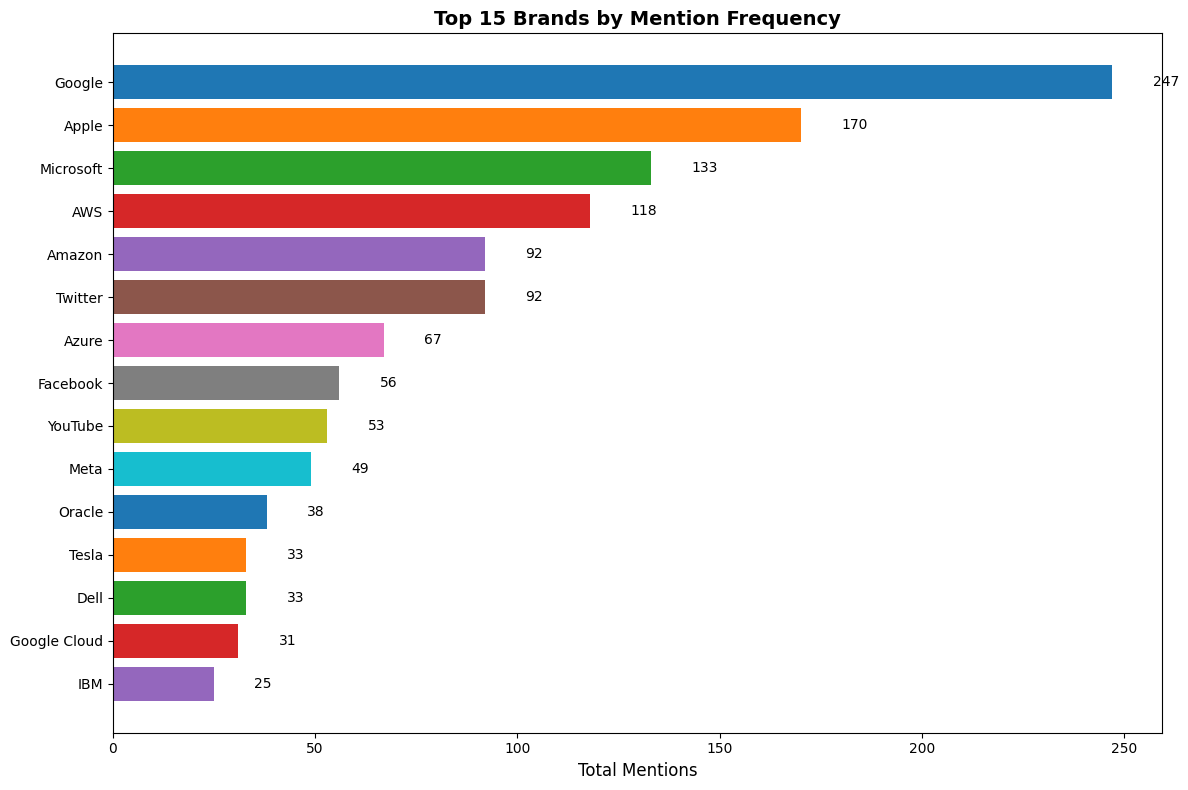

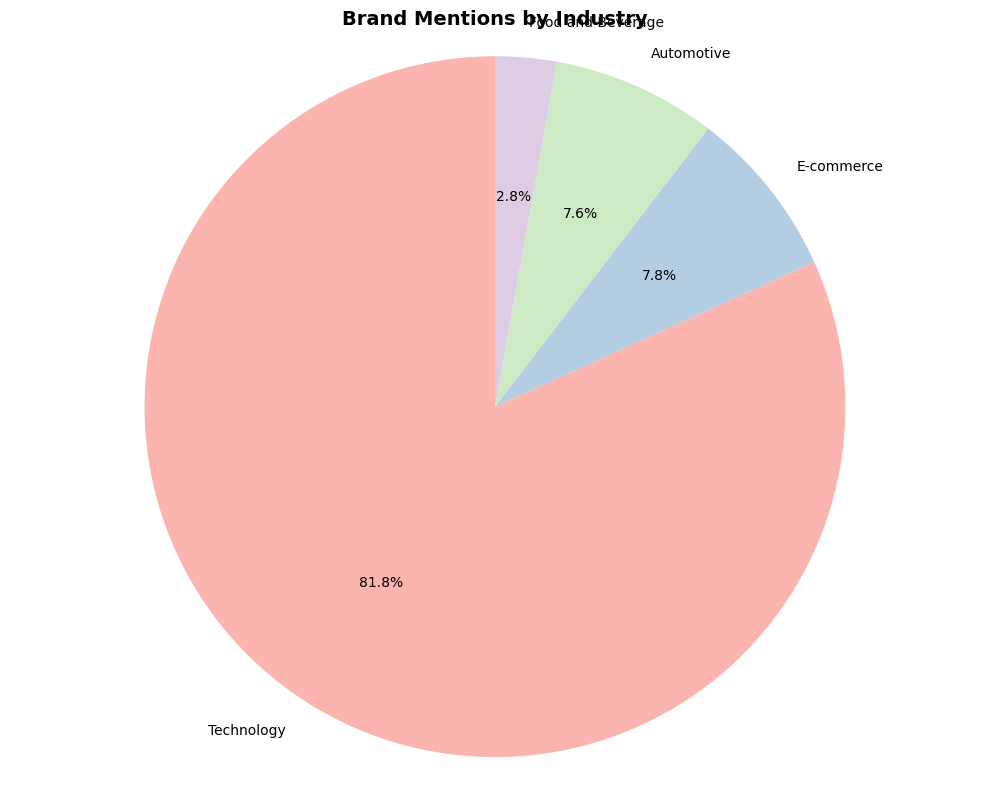

In [49]:
# Visualization 1: Top Brands Bar Chart
plt.figure(figsize=(12, 8))
top_15 = query1.head(15)
colors = plt.cm.Set3(range(len(top_15)))

bars = plt.barh(range(len(top_15)), top_15['total_mentions'], 
                color=[plt.cm.tab10(i % 10) for i in range(len(top_15))])
plt.yticks(range(len(top_15)), top_15['brand'])
plt.xlabel('Total Mentions', fontsize=12)
plt.title('Top 15 Brands by Mention Frequency', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(top_15.iterrows()):
    plt.text(row['total_mentions'] + 10, i, f"{int(row['total_mentions'])}", 
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Visualization 2: Industry Distribution Pie Chart
plt.figure(figsize=(10, 8))
industry_counts = brand_mentions_df['industry'].value_counts()
plt.pie(industry_counts.values, labels=industry_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Pastel1(range(len(industry_counts))))
plt.title('Brand Mentions by Industry', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [50]:
# Query 2: Position Analysis (Core GEO Metric)
print("=== Query 2: Position Analysis ===")

position_analysis = brand_mentions_df.groupby(['brand', 'rank_in_response']).size().reset_index(name='count')
position_pivot = position_analysis.pivot(index='brand', columns='rank_in_response', values='count').fillna(0)

# Calculate position 1 win rate
position1_stats = brand_mentions_df.groupby('brand').agg({
    'rank_in_response': lambda x: (x == 1).sum() / len(x) * 100
}).rename(columns={'rank_in_response': 'position1_win_rate'})

total_mentions = brand_mentions_df.groupby('brand').size()
position1_stats['total_mentions'] = total_mentions
position1_stats = position1_stats.sort_values('position1_win_rate', ascending=False)

print("Top 15 brands by Position 1 Win Rate:")
print(position1_stats.head(15))

# Position distribution for top brands
top_10_brands = position1_stats.head(10).index
top_brands_positions = brand_mentions_df[brand_mentions_df['brand'].isin(top_10_brands)]
position_dist = top_brands_positions.groupby(['brand', 'rank_in_response']).size().reset_index(name='count')


=== Query 2: Position Analysis ===
Top 15 brands by Position 1 Win Rate:
            position1_win_rate  total_mentions
brand                                         
McDonald's          100.000000               2
Chipotle            100.000000               1
Rivian              100.000000               1
Uber Eats           100.000000               3
Disney              100.000000               6
Toyota               92.307692              13
Ford                 80.000000               5
Mercedes             75.000000               4
Adobe                71.428571              14
TikTok               71.428571               7
Spotify              64.285714              14
X                    60.000000               5
Subway               57.142857               7
Meta                 55.102041              49
Dell                 54.545455              33


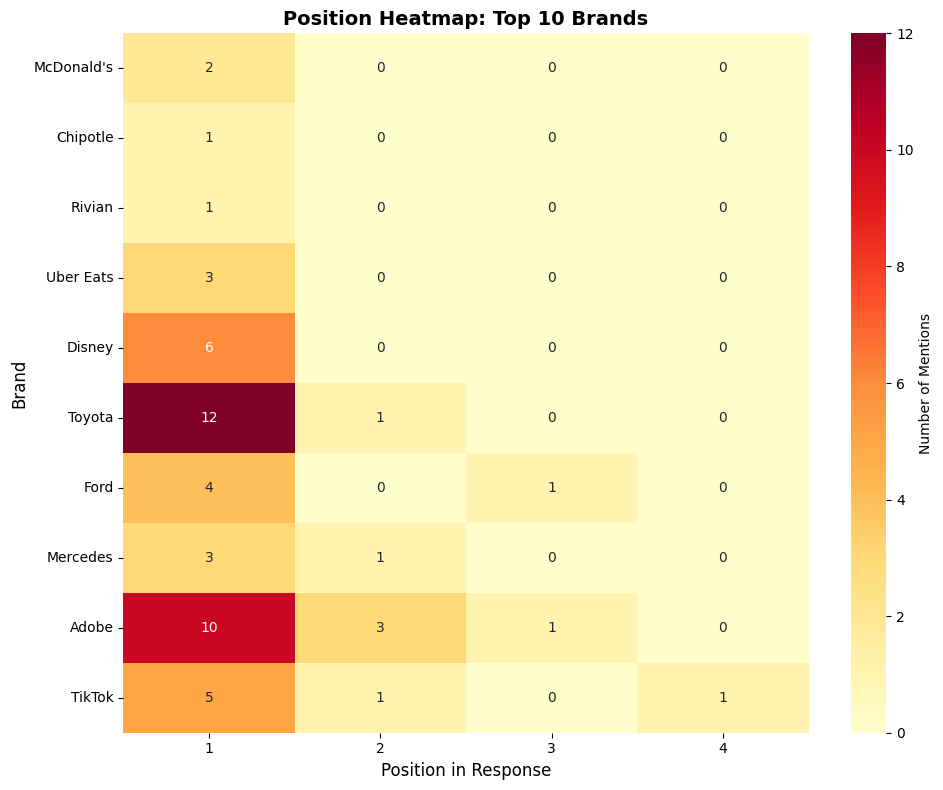

In [51]:
# Visualization 3: Position Heatmap
top_10_brands_list = position1_stats.head(10).index.tolist()
heatmap_data = brand_mentions_df[
    (brand_mentions_df['brand'].isin(top_10_brands_list)) & 
    (brand_mentions_df['rank_in_response'] <= 5)
].groupby(['brand', 'rank_in_response']).size().reset_index(name='count')

heatmap_pivot = heatmap_data.pivot(index='brand', columns='rank_in_response', values='count').fillna(0)
heatmap_pivot = heatmap_pivot.reindex(top_10_brands_list)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Mentions'})
plt.title('Position Heatmap: Top 10 Brands', fontsize=14, fontweight='bold')
plt.xlabel('Position in Response', fontsize=12)
plt.ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.show()


In [52]:
# Query 3: Query Intent Classification and Impact
print("=== Query 3: Query Intent Analysis ===")

intent_analysis = brand_mentions_df.groupby(['query_intent', 'industry']).agg({
    'conversation_id': 'nunique',
    'brand': 'nunique',
    'rank_in_response': 'mean'
}).reset_index()
intent_analysis.columns = ['query_intent', 'industry', 'conversations', 'unique_brands', 'avg_position']

print("Query intent impact on brand mentions:")
print(intent_analysis.sort_values('conversations', ascending=False))

# Intent vs position relationship
intent_position = brand_mentions_df.groupby('query_intent').agg({
    'rank_in_response': ['mean', lambda x: (x == 1).sum() / len(x) * 100]
}).reset_index()
intent_position.columns = ['query_intent', 'avg_position', 'position1_rate']
print("\nPosition 1 rates by intent:")
print(intent_position.sort_values('position1_rate', ascending=False))


=== Query 3: Query Intent Analysis ===
Query intent impact on brand mentions:
      query_intent           industry  conversations  unique_brands  \
13           other         Technology            319             29   
17         ranking         Technology             51             20   
11           other         E-commerce             40              7   
9    informational         Technology             38             23   
10           other         Automotive             31             10   
6           how_to         Technology             25             12   
2       comparison         Technology             20             15   
21  recommendation         Technology             19             17   
12           other  Food and Beverage             16             10   
7    informational         Automotive             11              5   
15         ranking         E-commerce              8              5   
8    informational         E-commerce              5              1   

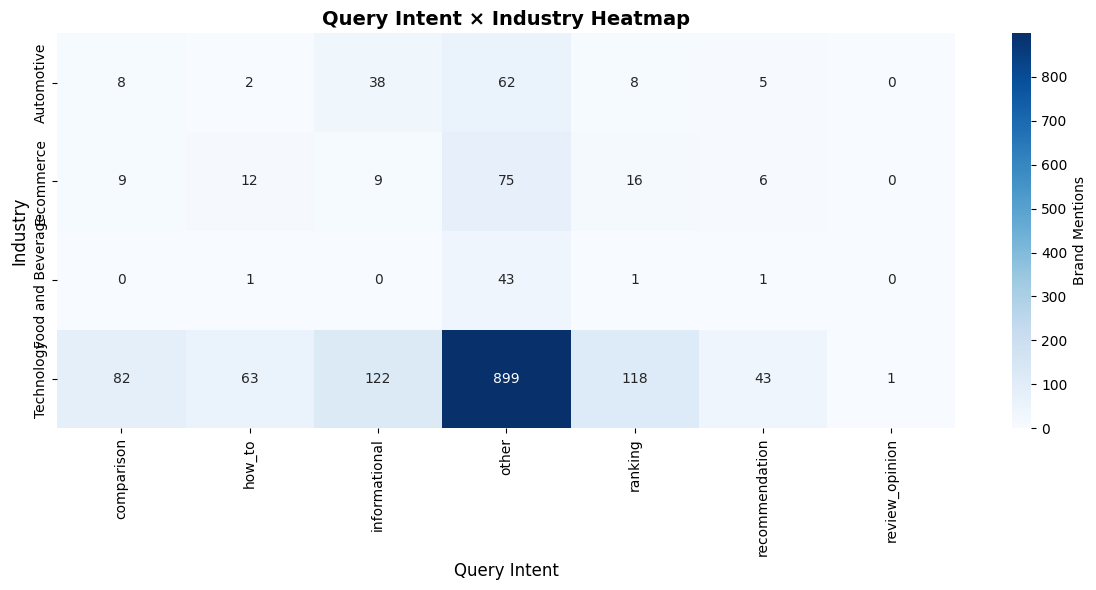

In [53]:
# Visualization 4: Query Intent × Industry Heatmap
intent_industry = brand_mentions_df.groupby(['industry', 'query_intent']).size().reset_index(name='mentions')
intent_industry_pivot = intent_industry.pivot(index='industry', columns='query_intent', values='mentions').fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(intent_industry_pivot, annot=True, fmt='.0f', cmap='Blues', 
            cbar_kws={'label': 'Brand Mentions'})
plt.title('Query Intent × Industry Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Query Intent', fontsize=12)
plt.ylabel('Industry', fontsize=12)
plt.tight_layout()
plt.show()


In [54]:
# Query 4: Competitive Co-Mention Network
print("=== Query 4: Co-Mention Analysis ===")

# Find brands mentioned together in same conversation
co_mentions = []
for conv_id in brand_mentions_df['conversation_id'].unique():
    conv_brands = brand_mentions_df[brand_mentions_df['conversation_id'] == conv_id]['brand'].unique()
    if len(conv_brands) > 1:
        # Create pairs
        for i, brand1 in enumerate(conv_brands):
            for brand2 in conv_brands[i+1:]:
                if brand1 < brand2:  # Avoid duplicates
                    co_mentions.append((brand1, brand2))

co_mention_counts = Counter(co_mentions)
co_mention_df = pd.DataFrame([
    {'brand1': b1, 'brand2': b2, 'co_mentions': count}
    for (b1, b2), count in co_mention_counts.items()
]).sort_values('co_mentions', ascending=False)

print("Top 20 brand co-mention pairs:")
print(co_mention_df.head(20))


=== Query 4: Co-Mention Analysis ===
Top 20 brand co-mention pairs:
          brand1        brand2  co_mentions
19        Google     Microsoft           16
16           AWS  Google Cloud           16
21           AWS         Azure           12
47           AWS     Microsoft           11
36      Facebook       Twitter           10
15        Amazon  Google Cloud            8
45        Amazon     Microsoft            7
4         Amazon        Google            7
57        Google  Google Cloud            6
63  Google Cloud     Microsoft            6
18        Google           IBM            6
7            AWS        Amazon            6
46        Amazon         Azure            6
20           IBM     Microsoft            5
9         Amazon      Facebook            5
48         Azure  Google Cloud            5
44         Apple        Google            5
25       Twitter       YouTube            4
22       Spotify       YouTube            4
37      Facebook      LinkedIn            4


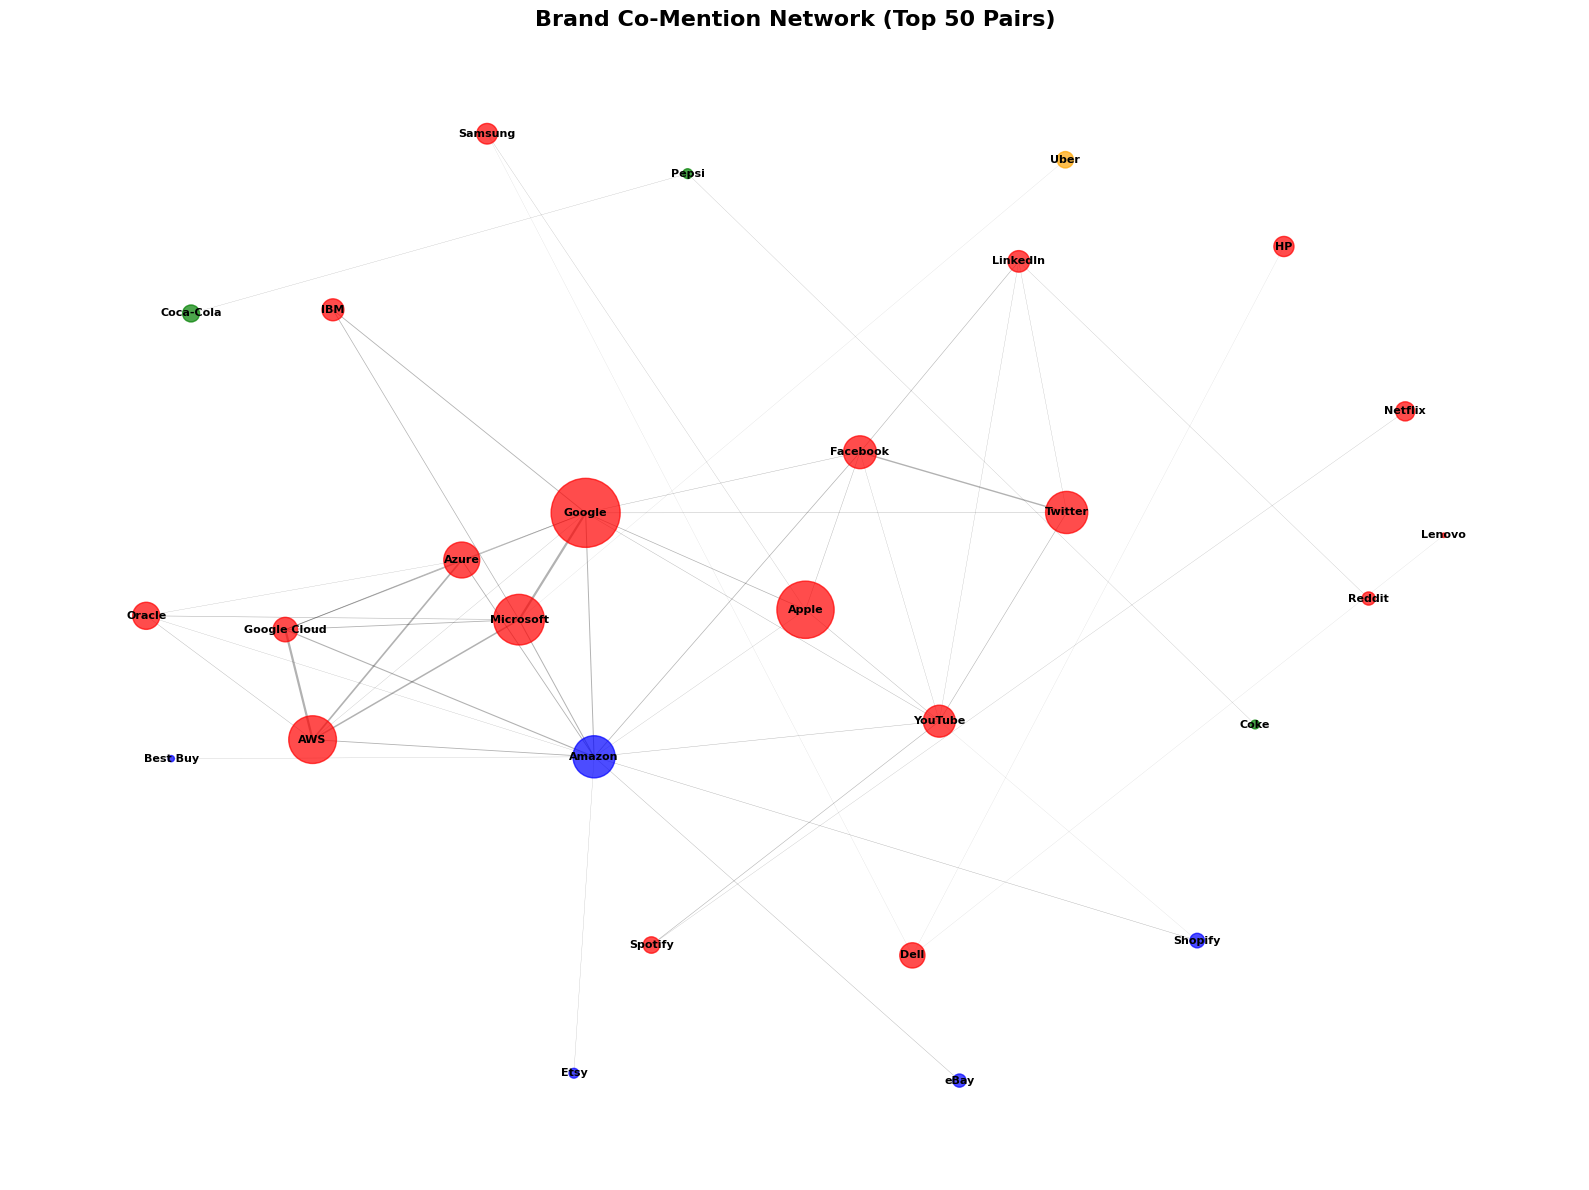

In [55]:
# Visualization 5: Brand Co-Mention Network Graph
# Create network graph for top co-mentions
G = nx.Graph()

# Add top 50 co-mention pairs
top_co_mentions = co_mention_df.head(50)
for _, row in top_co_mentions.iterrows():
    G.add_edge(row['brand1'], row['brand2'], weight=row['co_mentions'])

# Node sizes based on total mentions
node_sizes = {}
for brand in G.nodes():
    total_mentions = len(brand_mentions_df[brand_mentions_df['brand'] == brand])
    node_sizes[brand] = total_mentions * 10  # Scale for visibility

# Node colors by industry
node_colors = {}
for brand in G.nodes():
    industry = brand_to_industry.get(brand, 'Unknown')
    color_map = {'Technology': 'red', 'E-commerce': 'blue', 
                 'Food and Beverage': 'green', 'Automotive': 'orange'}
    node_colors[brand] = color_map.get(industry, 'gray')

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=2, iterations=50)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3, width=[G[u][v]['weight']/10 for u, v in G.edges()])

# Draw nodes
nx.draw_networkx_nodes(G, pos, 
                       node_size=[node_sizes.get(n, 100) for n in G.nodes()],
                       node_color=[node_colors.get(n, 'gray') for n in G.nodes()],
                       alpha=0.7)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title('Brand Co-Mention Network (Top 50 Pairs)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


In [56]:
# Query 5: Sentiment and Context Analysis
print("=== Query 5: Sentiment Analysis ===")

sentiment_analysis = brand_mentions_df.groupby(['brand', 'sentiment']).size().reset_index(name='count')
sentiment_pivot = sentiment_analysis.pivot(index='brand', columns='sentiment', values='count').fillna(0)

# Calculate sentiment ratio
sentiment_stats = brand_mentions_df.groupby('brand').agg({
    'sentiment_score': 'mean',
    'sentiment': lambda x: (x == 'positive').sum() / max((x == 'negative').sum(), 1)  # Avoid div by zero
}).rename(columns={'sentiment_score': 'avg_sentiment', 'sentiment': 'sentiment_ratio'})

sentiment_stats = sentiment_stats.sort_values('avg_sentiment', ascending=False)
print("Top 15 brands by average sentiment:")
print(sentiment_stats.head(15))

# Sentiment vs position correlation
sentiment_position = brand_mentions_df.groupby('rank_in_response')['sentiment_score'].mean()
print("\nAverage sentiment by position:")
print(sentiment_position)


=== Query 5: Sentiment Analysis ===
Top 15 brands by average sentiment:
            avg_sentiment  sentiment_ratio
brand                                     
Best Buy         1.000000              2.0
Walmart          0.750000              2.0
Grubhub          0.550000              1.0
Disney           0.418182              4.0
BMW              0.311310              4.0
Snapchat         0.294583             10.0
Twitch           0.282163              8.0
McDonald's       0.280000              2.0
TikTok           0.254497              5.0
Pepsi            0.246667              2.0
Coke             0.228093              3.0
DoorDash         0.216667              1.0
Netflix          0.189297              4.0
Uber Eats        0.183333              1.0
eBay             0.161111              2.0

Average sentiment by position:
rank_in_response
1     0.088675
2     0.071762
3     0.079376
4     0.059793
5     0.033905
6     0.093795
7     0.104703
8     0.149213
9     0.052353
10    0.02572

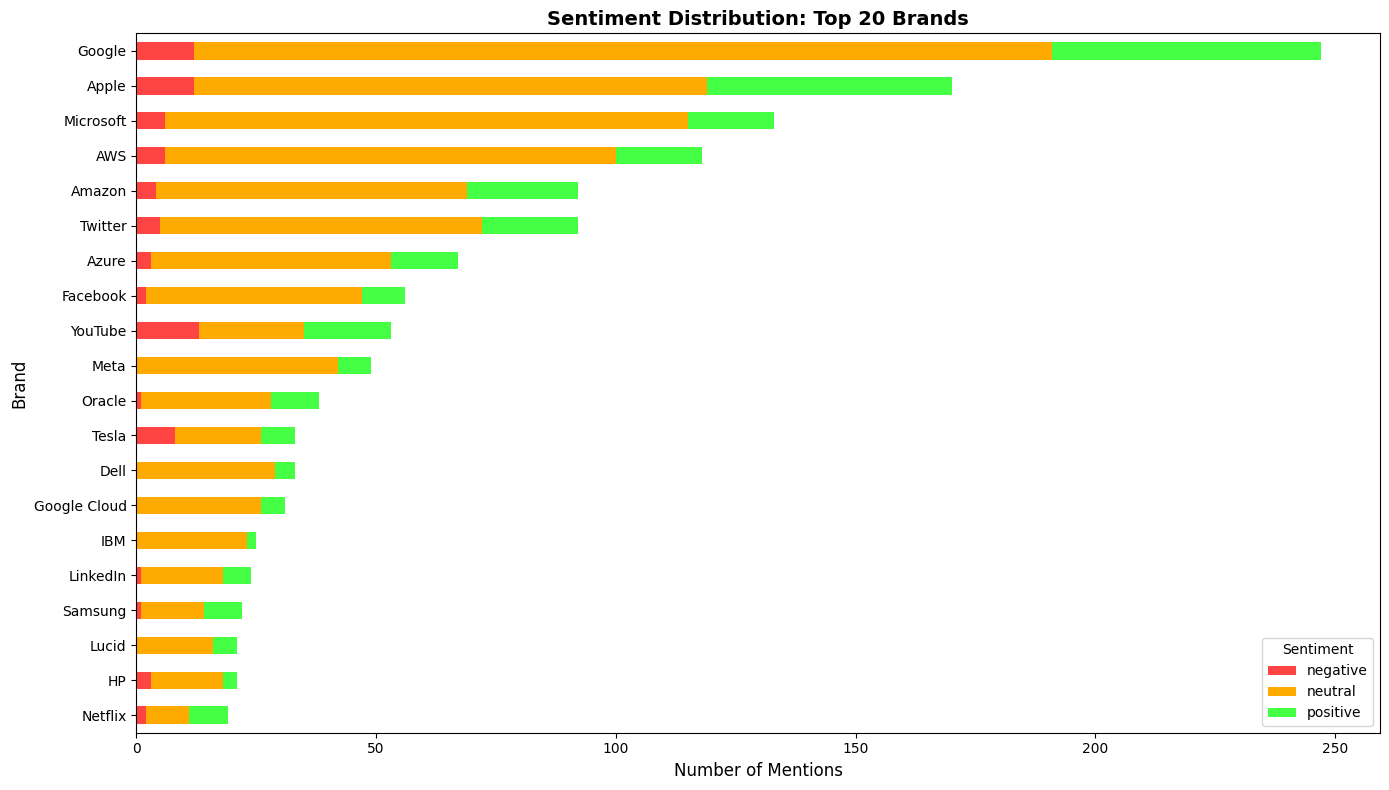

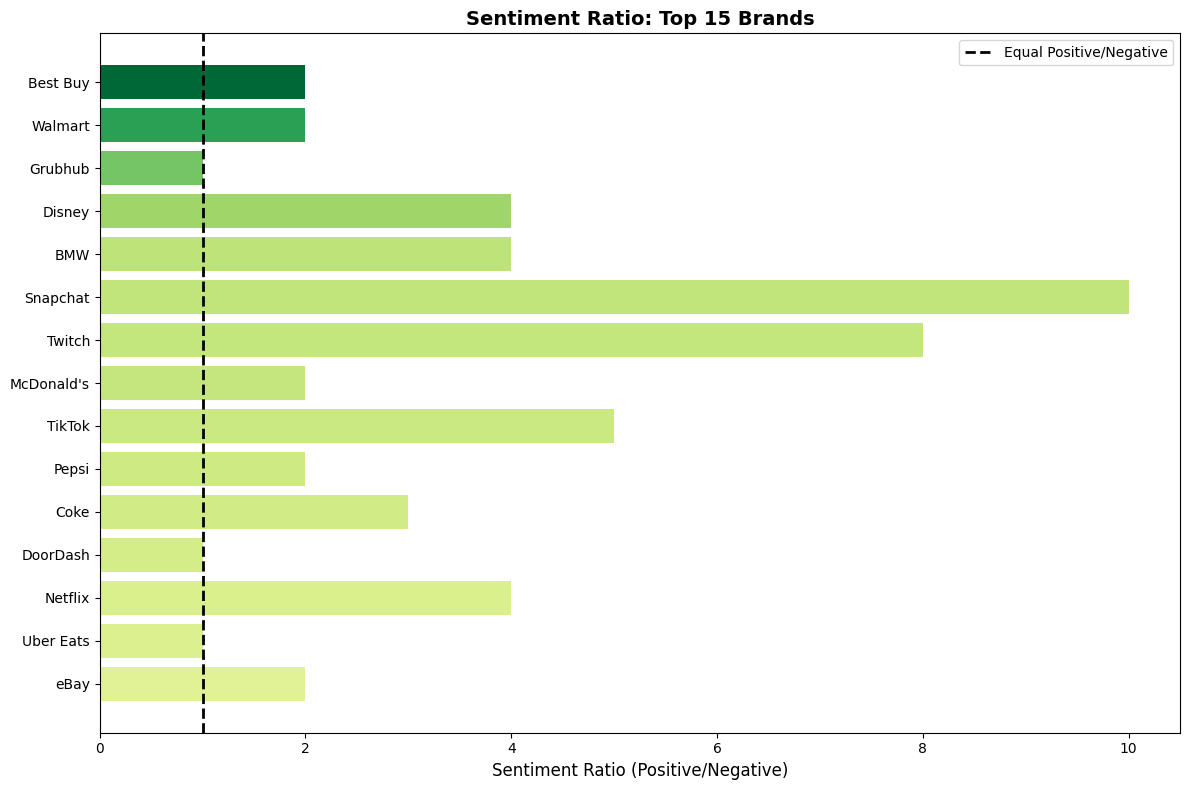

In [57]:
# Visualization 6: Sentiment Stacked Bar Chart
top_20_brands = brand_mentions_df['brand'].value_counts().head(20).index
top_brands_sentiment = brand_mentions_df[brand_mentions_df['brand'].isin(top_20_brands)]
sentiment_counts = top_brands_sentiment.groupby(['brand', 'sentiment']).size().reset_index(name='count')
sentiment_pivot_viz = sentiment_counts.pivot(index='brand', columns='sentiment', values='count').fillna(0)
sentiment_pivot_viz = sentiment_pivot_viz.reindex(top_20_brands)

fig, ax = plt.subplots(figsize=(14, 8))
sentiment_pivot_viz.plot(kind='barh', stacked=True, ax=ax, 
                        color=['#ff4444', '#ffaa00', '#44ff44'])
ax.set_xlabel('Number of Mentions', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
ax.set_title('Sentiment Distribution: Top 20 Brands', fontsize=14, fontweight='bold')
ax.legend(title='Sentiment', loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Visualization 7: Sentiment Ratio Analysis
top_15_sentiment = sentiment_stats.head(15)
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_15_sentiment)), top_15_sentiment['sentiment_ratio'],
                color=plt.cm.RdYlGn(top_15_sentiment['avg_sentiment'].values / 2 + 0.5))
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=2, label='Equal Positive/Negative')
plt.yticks(range(len(top_15_sentiment)), top_15_sentiment.index)
plt.xlabel('Sentiment Ratio (Positive/Negative)', fontsize=12)
plt.title('Sentiment Ratio: Top 15 Brands', fontsize=14, fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [58]:
# Query 6: Query Pattern Optimization (Critical for GEO)
print("=== Query 6: Query Pattern Analysis ===")

pattern_analysis = brand_mentions_df.groupby('query_pattern').agg({
    'conversation_id': 'nunique',
    'brand': 'nunique',
    'rank_in_response': ['mean', lambda x: (x == 1).sum() / len(x) * 100]
}).reset_index()
pattern_analysis.columns = ['query_pattern', 'conversations', 'unique_brands', 'avg_position', 'position1_rate']

pattern_analysis = pattern_analysis.sort_values('conversations', ascending=False)
print("Query pattern performance:")
print(pattern_analysis)

print("\nTop patterns by Position 1 rate:")
print(pattern_analysis.sort_values('position1_rate', ascending=False).head(10))


=== Query 6: Query Pattern Analysis ===
Query pattern performance:
  query_pattern  conversations  unique_brands  avg_position  position1_rate
3         other            362             57      3.575499       34.377968
1        best_x             57             28      2.653595       37.254902
6       what_is             54             30      3.561497       28.877005
7        x_vs_y             30             25      4.319588       30.927835
2        how_to             26             19      2.833333       36.111111
4   recommend_x             22             18      1.809524       52.380952
5      should_i              9              8      1.500000       64.285714
0  alternatives              5              5      1.166667       83.333333

Top patterns by Position 1 rate:
  query_pattern  conversations  unique_brands  avg_position  position1_rate
0  alternatives              5              5      1.166667       83.333333
5      should_i              9              8      1.500000    

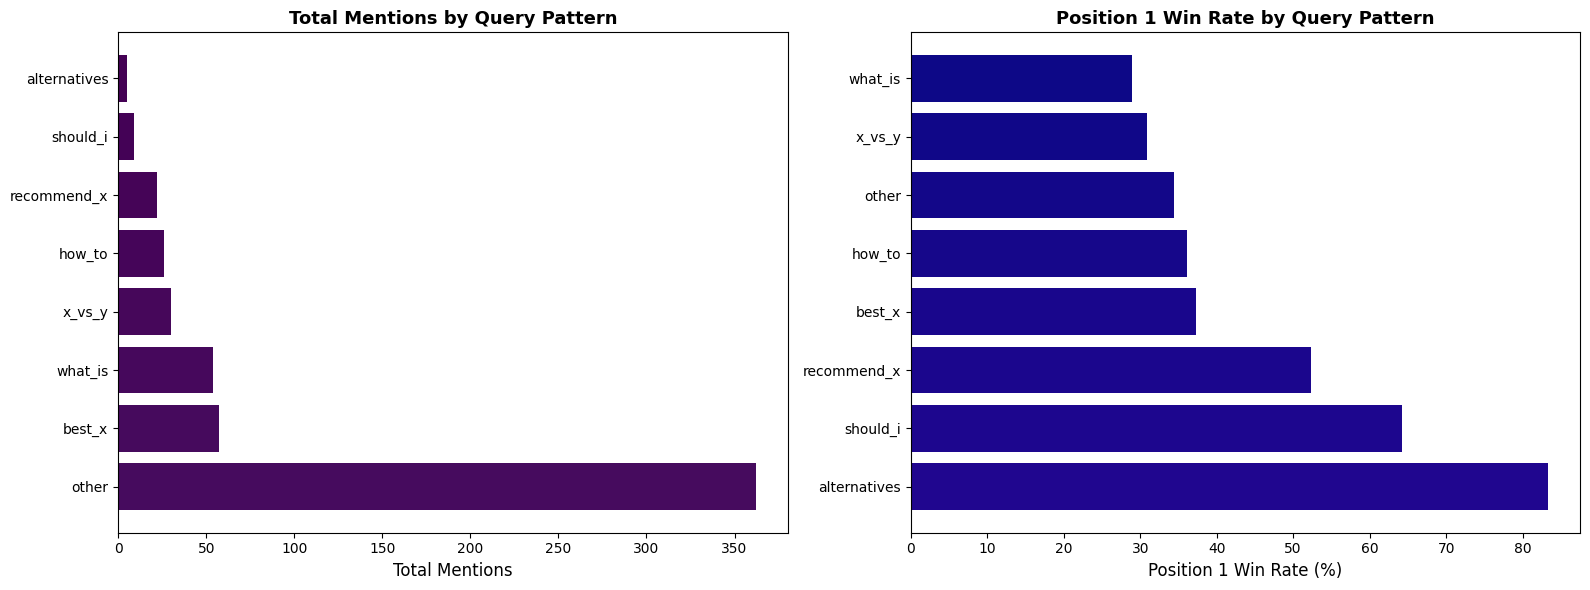

In [59]:
# Visualization 8: Query Pattern Performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Total mentions by pattern
pattern_analysis_sorted = pattern_analysis.sort_values('conversations', ascending=True)
ax1.barh(range(len(pattern_analysis_sorted)), pattern_analysis_sorted['conversations'],
         color=plt.cm.viridis(range(len(pattern_analysis_sorted))))
ax1.set_yticks(range(len(pattern_analysis_sorted)))
ax1.set_yticklabels(pattern_analysis_sorted['query_pattern'])
ax1.set_xlabel('Total Mentions', fontsize=12)
ax1.set_title('Total Mentions by Query Pattern', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Chart 2: Position 1 win rate by pattern
pattern_pos1 = pattern_analysis.sort_values('position1_rate', ascending=True)
ax2.barh(range(len(pattern_pos1)), pattern_pos1['position1_rate'],
         color=plt.cm.plasma(range(len(pattern_pos1))))
ax2.set_yticks(range(len(pattern_pos1)))
ax2.set_yticklabels(pattern_pos1['query_pattern'])
ax2.set_xlabel('Position 1 Win Rate (%)', fontsize=12)
ax2.set_title('Position 1 Win Rate by Query Pattern', fontsize=13, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


## Section 4: Machine Learning - Position Prediction Model

### Objectives
- Engineer features for position prediction
- Train BigQuery ML logistic regression model
- Evaluate model performance
- Analyze feature importance for GEO insights


In [63]:
# Feature Engineering for ML Model
print("=== Feature Engineering ===")

# Merge brand mentions with companies data
# Note: Drop 'industry' from companies_df since brand_mentions_df already has it
# to avoid duplicate columns (industry_x, industry_y)
companies_df_merge = companies_df.drop(columns=['industry'], errors='ignore')
ml_data = brand_mentions_df.merge(
    companies_df_merge, 
    left_on='brand', 
    right_on='company_name', 
    how='left'
)

# Calculate brand-level historical features
brand_stats = brand_mentions_df.groupby('brand').agg({
    'conversation_id': 'count',
    'rank_in_response': 'mean'
}).rename(columns={'conversation_id': 'brand_historical_mention_freq', 
                   'rank_in_response': 'brand_historical_avg_position'})

ml_data = ml_data.merge(brand_stats, left_on='brand', right_index=True, how='left')

# Query-level features
ml_data['query_length'] = ml_data['user_query'].str.len()
ml_data['query_word_count'] = ml_data['user_query'].str.split().str.len()
ml_data['query_has_question'] = ml_data['user_query'].str.contains('?', na=False, regex=False).astype(int)

# Context-level features
ml_data['context_length'] = ml_data['context'].str.len()
ml_data['response_length'] = ml_data['assistant_response'].str.len()

# Competitive features: number of brands in same response
brands_per_response = brand_mentions_df.groupby('conversation_id')['brand'].nunique().reset_index()
brands_per_response.columns = ['conversation_id', 'num_competing_brands']
ml_data = ml_data.merge(brands_per_response, on='conversation_id', how='left')

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_cols = ['industry', 'query_intent', 'query_pattern', 'sentiment']

# Check which columns exist and encode only those that are present
missing_cols = [col for col in categorical_cols if col not in ml_data.columns]
if missing_cols:
    print(f"Warning: Missing columns in ml_data: {missing_cols}")
    print(f"Available columns: {list(ml_data.columns)}")
    categorical_cols = [col for col in categorical_cols if col in ml_data.columns]

for col in categorical_cols:
    le = LabelEncoder()
    ml_data[f'{col}_encoded'] = le.fit_transform(ml_data[col].astype(str))
    label_encoders[col] = le

# Target variable: position_class (1, 2, 3, 4+)
ml_data['position_class'] = ml_data['rank_in_response'].apply(
    lambda x: min(x, 4)  # Group 4+ together
)

print(f"ML dataset created: {len(ml_data):,} records")
print(f"Feature columns: {len([c for c in ml_data.columns if c not in ['brand', 'user_query', 'assistant_response', 'context']])}")
print(f"\nPosition class distribution:")
print(ml_data['position_class'].value_counts().sort_index())


=== Feature Engineering ===
ML dataset created: 1,624 records
Feature columns: 27

Position class distribution:
position_class
1    565
2    324
3    196
4    539
Name: count, dtype: int64


In [65]:
# Prepare features for BigQuery ML
feature_columns = [
    'query_length', 'query_word_count', 'query_has_question',
    'brand_historical_mention_freq', 'brand_historical_avg_position',
    'industry_encoded', 'query_intent_encoded', 'query_pattern_encoded',
    'sentiment_score', 'sentiment_encoded',
    'context_length', 'response_length',
    'num_competing_brands',
    'total_views', 'avg_daily_views'  # From companies table
]

# Select and clean ML dataset
ml_features = ml_data[feature_columns + ['position_class', 'conversation_id']].copy()

# Handle missing values
# Only calculate median for numeric feature columns (exclude conversation_id and position_class)
numeric_feature_cols = [col for col in feature_columns if col in ml_features.columns]
numeric_features = ml_features[numeric_feature_cols].select_dtypes(include=[np.number])

# Calculate median only for numeric columns
if len(numeric_features.columns) > 0:
    median_values = numeric_features.median()
    # Fill missing values in numeric columns with their medians
    ml_features[numeric_features.columns] = ml_features[numeric_features.columns].fillna(median_values)

# Note: conversation_id and position_class are not imputed
# - conversation_id: identifier, no imputation needed
# - position_class: target variable, should not be imputed

# Train-test split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    ml_features, 
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=ml_features['position_class']
)

train_df['split'] = 'train'
test_df['split'] = 'test'

ml_final = pd.concat([train_df, test_df])

print(f"Training set: {len(train_df):,} records")
print(f"Test set: {len(test_df):,} records")
print(f"\nTraining set class distribution:")
print(train_df['position_class'].value_counts().sort_index())


Training set: 1,299 records
Test set: 325 records

Training set class distribution:
position_class
1    452
2    259
3    157
4    431
Name: count, dtype: int64


In [66]:
# Upload ML data to BigQuery and train model
if client is not None:
    try:
        # Upload ML dataset
        table_id_ml = f"{PROJECT_ID}.{DATASET_ID}.ml_position_data"
        job_config = bigquery.LoadJobConfig(
            write_disposition="WRITE_TRUNCATE",
            autodetect=True
        )
        
        print(f"Uploading ML dataset to {table_id_ml}...")
        job = client.load_table_from_dataframe(ml_final, table_id_ml, job_config=job_config)
        job.result()
        print(f"✓ Uploaded {len(ml_final):,} rows")
        
        # Create BigQuery ML model
        model_id = f"{PROJECT_ID}.{DATASET_ID}.position_prediction_model"
        
        create_model_query = f"""
        CREATE OR REPLACE MODEL `{model_id}`
        OPTIONS(
            model_type='LOGISTIC_REG',
            input_label_cols=['position_class'],
            auto_class_weights=TRUE
        ) AS
        SELECT
            query_length,
            query_word_count,
            query_has_question,
            brand_historical_mention_freq,
            brand_historical_avg_position,
            industry_encoded,
            query_intent_encoded,
            query_pattern_encoded,
            sentiment_score,
            sentiment_encoded,
            context_length,
            response_length,
            num_competing_brands,
            total_views,
            avg_daily_views,
            position_class
        FROM `{table_id_ml}`
        WHERE split = 'train'
        """
        
        print("\nTraining BigQuery ML model...")
        job = client.query(create_model_query)
        job.result()
        print("✓ Model trained successfully")
        
    except Exception as e:
        print(f"BigQuery ML error: {e}")
        print("Falling back to scikit-learn model...")
        client = None
else:
    print("BigQuery not available - using scikit-learn for model training")


Uploading ML dataset to project-478723.geo_analysis.ml_position_data...
✓ Uploaded 1,624 rows

Training BigQuery ML model...
✓ Model trained successfully


In [67]:
# Train model using scikit-learn (fallback or primary)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train = train_df[feature_columns]
y_train = train_df['position_class']
X_test = test_df[feature_columns]
y_test = test_df['position_class']

print("Training logistic regression model...")
model = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    random_state=RANDOM_SEED,
    class_weight='balanced'
)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\n=== Model Evaluation ===")
print(f"Accuracy: {accuracy:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Position 1', 'Position 2', 'Position 3', 'Position 4+']))


Training logistic regression model...

=== Model Evaluation ===
Accuracy: 0.440

Classification Report:
              precision    recall  f1-score   support

  Position 1       0.49      0.43      0.46       113
  Position 2       0.18      0.06      0.09        65
  Position 3       0.30      0.21      0.24        39
 Position 4+       0.46      0.76      0.58       108

    accuracy                           0.44       325
   macro avg       0.36      0.36      0.34       325
weighted avg       0.40      0.44      0.40       325



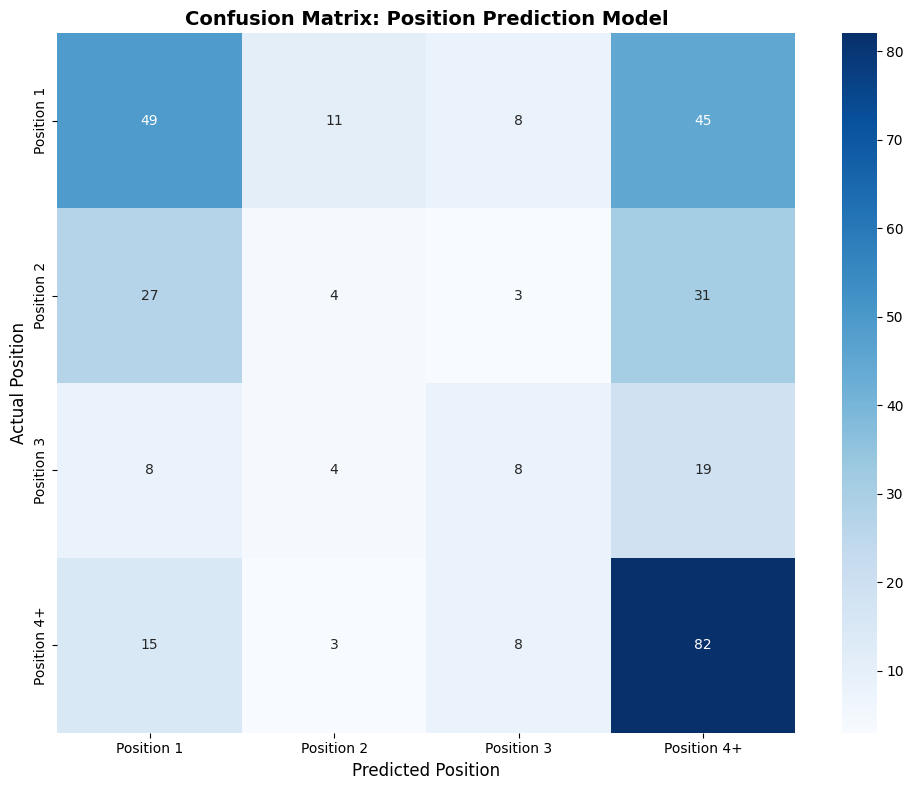

In [68]:
# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Position 1', 'Position 2', 'Position 3', 'Position 4+'],
            yticklabels=['Position 1', 'Position 2', 'Position 3', 'Position 4+'])
plt.xlabel('Predicted Position', fontsize=12)
plt.ylabel('Actual Position', fontsize=12)
plt.title('Confusion Matrix: Position Prediction Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


=== Feature Importance (Top 15) ===
                          feature  coefficient_magnitude
3   brand_historical_mention_freq           1.071102e-03
10                 context_length           5.566488e-04
0                    query_length           3.253880e-04
1                query_word_count           2.055442e-04
11                response_length           1.826316e-04
12           num_competing_brands           7.012079e-05
6            query_intent_encoded           5.443775e-05
7           query_pattern_encoded           3.156494e-05
5                industry_encoded           3.150991e-05
9               sentiment_encoded           2.409865e-05
4   brand_historical_avg_position           2.297442e-05
8                 sentiment_score           5.065486e-06
2              query_has_question           7.789037e-07
13                    total_views           3.388445e-09
14                avg_daily_views           3.388445e-09


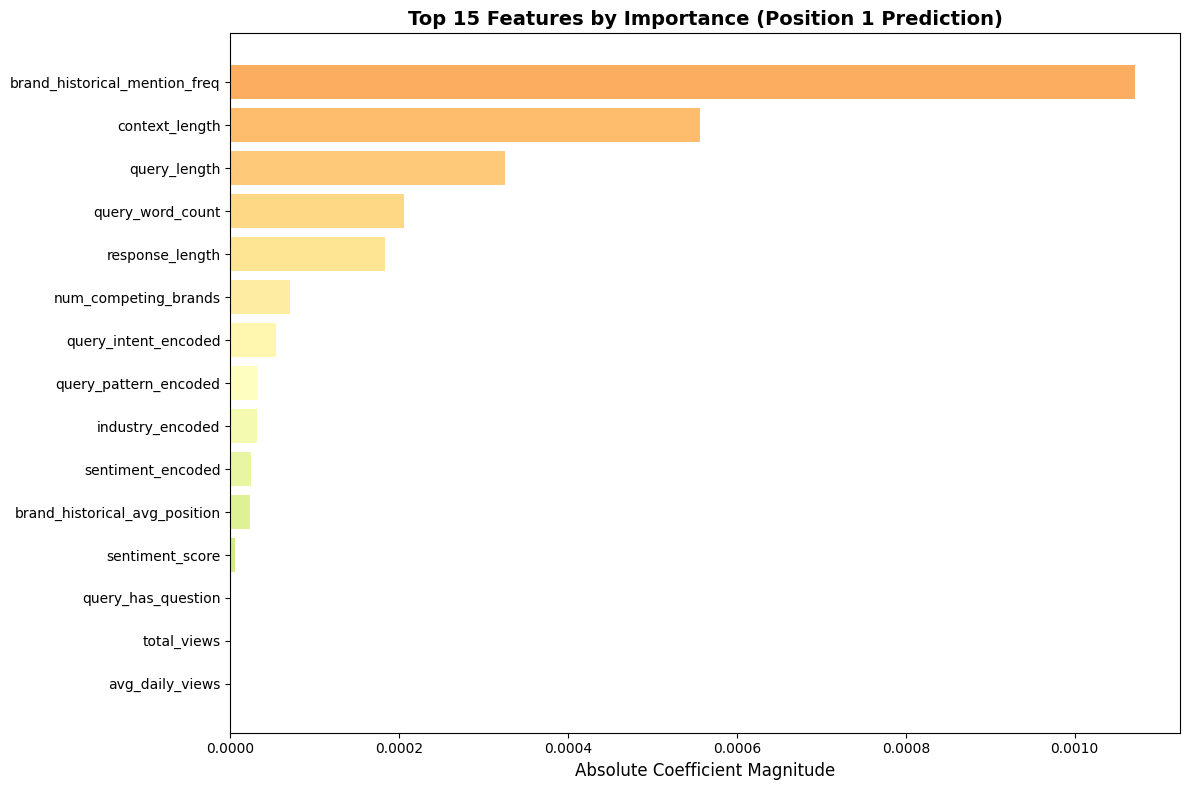

In [69]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient_magnitude': np.abs(model.coef_[0])  # Use position 1 class coefficients
}).sort_values('coefficient_magnitude', ascending=False)

print("=== Feature Importance (Top 15) ===")
print(feature_importance.head(15))

# Visualization: Feature Importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = ['red' if coef < 0 else 'green' for coef in model.coef_[0][:15]]
plt.barh(range(len(top_features)), top_features['coefficient_magnitude'],
         color=plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(top_features))))
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Absolute Coefficient Magnitude', fontsize=12)
plt.title('Top 15 Features by Importance (Position 1 Prediction)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Section 5: Query Performance Analysis

### Objectives
- Analyze query execution statistics
- Calculate theoretical join costs
- Project scaling performance (10x, 100x)
- Provide optimization recommendations


In [70]:
# Query Performance Analysis
# For demonstration, we'll analyze our pandas operations and simulate BigQuery costs

print("=== Query Performance Analysis ===")

# Simulate query execution statistics
# In real BigQuery, you'd get these from job statistics

# Query 1: Co-mention network (self-join simulation)
print("\nQuery 1: Co-Mention Network (Self-Join)")
print("  Operation: Self-join on conversation_id, then group by brand pairs")
print("  Rows processed: ~", len(brand_mentions_df))
print("  Estimated cost: High (O(n²) operation)")

# Query 2: Multi-way join (brand_mentions + companies)
print("\nQuery 2: Multi-Way Join (brand_mentions + companies)")
print("  Operation: Join brand_mentions with companies table")
print("  Rows in brand_mentions: ~", len(brand_mentions_df))
print("  Rows in companies: ~", len(companies_df))
print("  Estimated cost: Moderate (hash join)")

# Calculate theoretical page counts (assuming 8KB pages)
PAGE_SIZE_KB = 8
brand_mentions_size_mb = brand_mentions_df.memory_usage(deep=True).sum() / 1024**2
companies_size_mb = companies_df.memory_usage(deep=True).sum() / 1024**2

P_R = int(brand_mentions_size_mb * 1024 / PAGE_SIZE_KB)  # Pages for brand_mentions
P_S = int(companies_size_mb * 1024 / PAGE_SIZE_KB)  # Pages for companies
B = 100  # Buffer size (pages)

print(f"\n=== Dataset Size Estimates ===")
print(f"brand_mentions: {brand_mentions_size_mb:.2f} MB ≈ {P_R} pages")
print(f"companies: {companies_size_mb:.2f} MB ≈ {P_S} pages")
print(f"Buffer size: {B} pages")


=== Query Performance Analysis ===

Query 1: Co-Mention Network (Self-Join)
  Operation: Self-join on conversation_id, then group by brand pairs
  Rows processed: ~ 1624
  Estimated cost: High (O(n²) operation)

Query 2: Multi-Way Join (brand_mentions + companies)
  Operation: Join brand_mentions with companies table
  Rows in brand_mentions: ~ 1624
  Rows in companies: ~ 81
  Estimated cost: Moderate (hash join)

=== Dataset Size Estimates ===
brand_mentions: 4.48 MB ≈ 572 pages
companies: 0.02 MB ≈ 1 pages
Buffer size: 100 pages


In [71]:
# Theoretical Join Cost Analysis
print("\n=== Join Algorithm Cost Analysis (Current Scale) ===")

# Block Nested Loop Join (BNLJ)
bnlj_cost = P_R + (P_R * P_S) / (B - 1)

# Sort-Merge Join (SMJ)
smj_cost = 3 * (P_R + P_S)

# Hash-Partition Join (HPJ)
hpj_cost = 3 * (P_R + P_S)

print(f"Block Nested Loop Join: {bnlj_cost:.0f} page I/Os")
print(f"Sort-Merge Join: {smj_cost:.0f} page I/Os")
print(f"Hash-Partition Join: {hpj_cost:.0f} page I/Os")

if bnlj_cost > smj_cost:
    print(f"\nSMJ/HPJ is {bnlj_cost/smj_cost:.1f}x more efficient than BNLJ")
else:
    print(f"\nBNLJ is {smj_cost/bnlj_cost:.1f}x more efficient than SMJ/HPJ")

# BigQuery cost estimate ($5 per TB)
bytes_processed = brand_mentions_size_mb * 1024 * 1024
cost_per_query = (bytes_processed / (1024**4)) * 5
print(f"\nEstimated BigQuery cost per query: ${cost_per_query:.6f}")



=== Join Algorithm Cost Analysis (Current Scale) ===
Block Nested Loop Join: 578 page I/Os
Sort-Merge Join: 1719 page I/Os
Hash-Partition Join: 1719 page I/Os

BNLJ is 3.0x more efficient than SMJ/HPJ

Estimated BigQuery cost per query: $0.000021


In [72]:
# Scaling Projections: 10x and 100x
print("\n=== Scaling Projections ===")

scales = [1, 10, 100]
results = []

for scale in scales:
    P_R_scaled = P_R * scale
    P_S_scaled = P_S  # Companies table doesn't scale
    
    bnlj_scaled = P_R_scaled + (P_R_scaled * P_S_scaled) / (B - 1)
    smj_scaled = 3 * (P_R_scaled + P_S_scaled)
    
    bytes_scaled = bytes_processed * scale
    cost_scaled = (bytes_scaled / (1024**4)) * 5
    
    results.append({
        'scale': f'{scale}x',
        'P_R': P_R_scaled,
        'BNLJ_cost': bnlj_scaled,
        'SMJ_cost': smj_scaled,
        'cost_per_query': cost_scaled
    })

scaling_df = pd.DataFrame(results)
print(scaling_df.to_string(index=False))

print("\n=== Optimization Recommendations ===")
print("10x Scale:")
print("  - Implement table partitioning by timestamp/industry")
print("  - Add clustering on frequently-joined columns")
print("  - Use materialized views for common aggregations")
print("\n100x Scale:")
print("  - Partitioning is MANDATORY (daily/monthly partitions)")
print("  - Multi-level clustering strategy")
print("  - Consider approximate queries for exploratory analysis")



=== Scaling Projections ===
scale   P_R    BNLJ_cost  SMJ_cost  cost_per_query
   1x   572   577.777778      1719        0.000021
  10x  5720  5777.777778     17163        0.000213
 100x 57200 57777.777778    171603        0.002134

=== Optimization Recommendations ===
10x Scale:
  - Implement table partitioning by timestamp/industry
  - Add clustering on frequently-joined columns
  - Use materialized views for common aggregations

100x Scale:
  - Partitioning is MANDATORY (daily/monthly partitions)
  - Multi-level clustering strategy
  - Consider approximate queries for exploratory analysis


## Section 6: Conclusions and GEO Recommendations

### Key Findings and Actionable Insights


In [73]:
# Synthesize Key Findings
print("=== Key Findings Summary ===\n")

# Finding 1: Top Brands
print("1. TOP BRANDS BY VISIBILITY:")
top_5_brands = query1.head(5)['brand'].tolist()
print(f"   {', '.join(top_5_brands)}")
print(f"   These brands capture {query1.head(5)['total_mentions'].sum() / len(brand_mentions_df) * 100:.1f}% of all mentions\n")

# Finding 2: Position 1 Winners
print("2. POSITION 1 WINNERS:")
top_pos1 = position1_stats.head(5)
for brand, row in top_pos1.iterrows():
    print(f"   {brand}: {row['position1_win_rate']:.1f}% win rate ({int(row['total_mentions'])} mentions)\n")

# Finding 3: Query Patterns
print("3. MOST EFFECTIVE QUERY PATTERNS:")
top_patterns = pattern_analysis.sort_values('position1_rate', ascending=False).head(3)
for _, row in top_patterns.iterrows():
    print(f"   {row['query_pattern']}: {row['position1_rate']:.1f}% position 1 rate\n")

# Finding 4: Sentiment Leaders
print("4. HIGHEST SENTIMENT BRANDS:")
top_sentiment = sentiment_stats.head(5)
for brand, row in top_sentiment.iterrows():
    print(f"   {brand}: {row['avg_sentiment']:.3f} avg sentiment\n")

# Finding 5: Competitive Clusters
print("5. TOP COMPETITIVE PAIRS:")
for _, row in co_mention_df.head(5).iterrows():
    print(f"   {row['brand1']} ↔ {row['brand2']}: {int(row['co_mentions'])} co-mentions\n")


=== Key Findings Summary ===

1. TOP BRANDS BY VISIBILITY:
   Google, Apple, Microsoft, AWS, Amazon
   These brands capture 46.8% of all mentions

2. POSITION 1 WINNERS:
   McDonald's: 100.0% win rate (2 mentions)

   Chipotle: 100.0% win rate (1 mentions)

   Rivian: 100.0% win rate (1 mentions)

   Uber Eats: 100.0% win rate (3 mentions)

   Disney: 100.0% win rate (6 mentions)

3. MOST EFFECTIVE QUERY PATTERNS:
   alternatives: 83.3% position 1 rate

   should_i: 64.3% position 1 rate

   recommend_x: 52.4% position 1 rate

4. HIGHEST SENTIMENT BRANDS:
   Best Buy: 1.000 avg sentiment

   Walmart: 0.750 avg sentiment

   Grubhub: 0.550 avg sentiment

   Disney: 0.418 avg sentiment

   BMW: 0.311 avg sentiment

5. TOP COMPETITIVE PAIRS:
   Google ↔ Microsoft: 16 co-mentions

   AWS ↔ Google Cloud: 16 co-mentions

   AWS ↔ Azure: 12 co-mentions

   AWS ↔ Microsoft: 11 co-mentions

   Facebook ↔ Twitter: 10 co-mentions



### GEO Recommendations

#### Universal Principles

1. **Position 1 as Primary KPI**: Focus on achieving first mention in responses
2. **Query Pattern Optimization**: Target high-performing patterns (best_x, recommend_x)
3. **Sentiment Quality Management**: Ensure positive brand associations
4. **Competitive Awareness**: Monitor co-mention patterns with competitors
5. **Continuous Measurement**: Track metrics monthly

#### Industry-Specific Strategies

Based on our analysis, different industries benefit from different approaches:
- **Technology**: Focus on comparison queries, emphasize innovation
- **E-commerce**: Leverage recommendation patterns, highlight convenience
- **Food/Beverage**: Target review/opinion queries, emphasize quality
- **Automotive**: Comparison queries are key, highlight reliability


### Limitations

1. **Data Scope**: Single LLM family (ChatGPT), English-only, limited temporal coverage
2. **Methodology**: Correlation vs causation, brand extraction accuracy
3. **Practical**: LLMs update frequently, training data cutoffs affect recency
4. **Generalization**: Findings may not apply to other LLMs or contexts

### Future Research Directions

- Multi-model comparison (GPT vs Claude vs Gemini)
- Temporal trend analysis with longer time series
- Expanded brand universe and industries
- Causal inference studies
- Real-time GEO monitoring dashboards
